<a href="https://colab.research.google.com/github/ChunHajin/wellbore-tvt-prediction/blob/main/ROGII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2주차 EDA

In [2]:
# [1] 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# [2] 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['font.size'] = 11

# 한글 폰트 설치 및 등록
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# [3] 경로 설정 & 데이터 로드
BASE_PATH = '/content/drive/MyDrive/ROGII'

WELL_NAME = '000d7d20'   # 분석할 웰 이름

hw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__horizontal_well.csv')
tw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__typewell.csv')

print(f'수평정 shape: {hw.shape}')
print(f'Typewell shape: {tw.shape}')

수평정 shape: (5278, 13)
Typewell shape: (1296, 3)


In [5]:
# [4] 기본 정보 확인
print('===== 수평정 컬럼 =====')
print(hw.dtypes)
print()
print('===== 수평정 기초 통계 =====')
print(hw.describe())

===== 수평정 컬럼 =====
MD           float64
X            float64
Y            float64
Z            float64
ANCC         float64
ASTNU        float64
ASTNL        float64
EGFDU        float64
EGFDL        float64
BUDA         float64
TVT          float64
GR           float64
TVT_input    float64
dtype: object

===== 수평정 기초 통계 =====
                 MD             X             Y            Z         ANCC  \
count   5278.000000  5.278000e+03  5.278000e+03  5278.000000  5278.000000   
mean   14105.500000  2.983514e+06  1.071418e+06 -9673.194324 -9330.621821   
std     1523.771691  2.997379e+01  1.503381e+03    80.961903    35.272977   
min    11467.000000  2.983468e+06  1.069022e+06 -9755.610000 -9395.810000   
25%    12786.250000  2.983487e+06  1.070090e+06 -9721.762500 -9362.307500   
50%    14105.500000  2.983514e+06  1.071407e+06 -9689.230000 -9335.975000   
75%    15424.750000  2.983535e+06  1.072723e+06 -9650.035000 -9296.665000   
max    16744.000000  2.983578e+06  1.074041e+06 -9258.5

In [6]:
# [5] NaN 현황 확인
print('===== 수평정 NaN 개수 =====')
nan_counts = hw.isnull().sum()
nan_pct = (nan_counts / len(hw) * 100).round(1)
nan_df = pd.DataFrame({'NaN 개수': nan_counts, 'NaN 비율(%)': nan_pct})
print(nan_df[nan_df['NaN 개수'] > 0])

print()
print('===== Typewell NaN 개수 =====')
print(tw.isnull().sum())

===== 수평정 NaN 개수 =====
           NaN 개수  NaN 비율(%)
GR           2258       42.8
TVT_input    3836       72.7

===== Typewell NaN 개수 =====
TVT          0
GR           0
Geology    299
dtype: int64


In [7]:
# [6] PS(Prediction Start) 지점 찾기
# TVT_input이 NaN이 아닌 마지막 행 = PS 직전
ps_idx = hw['TVT_input'].last_valid_index()
ps_md  = hw.loc[ps_idx, 'MD']

print(f'PS 지점 index : {ps_idx}')
print(f'PS 지점 MD    : {ps_md:.1f} ft')
print(f'PS 이전 구간  : {ps_idx + 1} 행')
print(f'PS 이후 구간  : {len(hw) - ps_idx - 1} 행  ← 예측 대상')

PS 지점 index : 1441
PS 지점 MD    : 12908.0 ft
PS 이전 구간  : 1442 행
PS 이후 구간  : 3836 행  ← 예측 대상


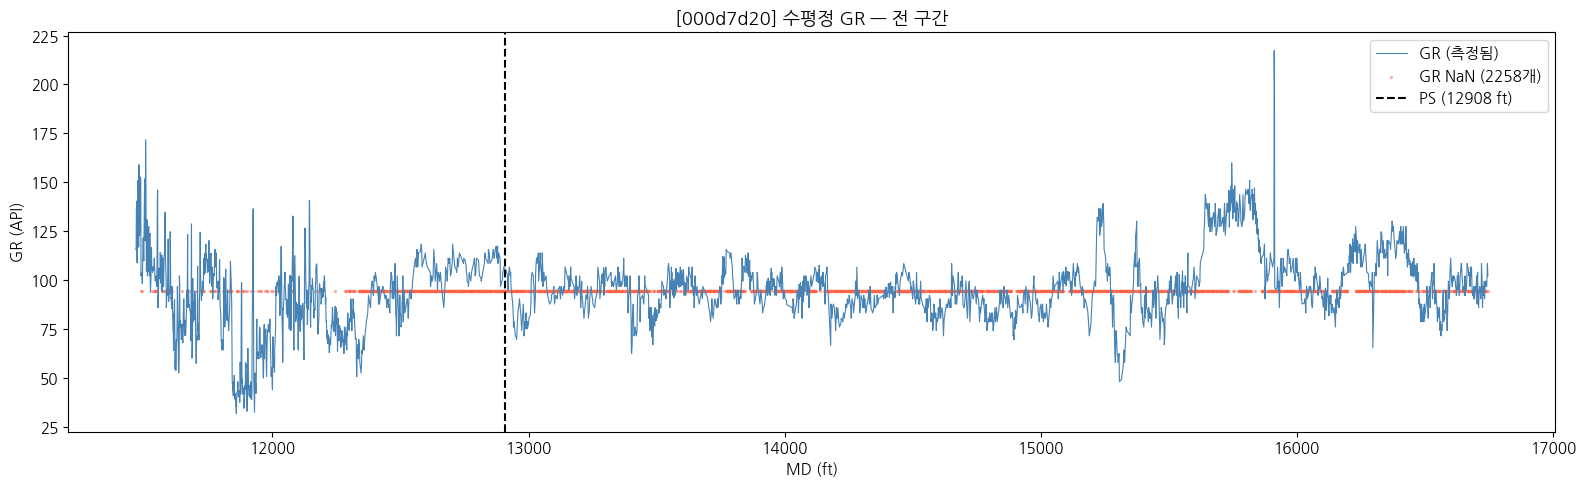

In [8]:
# [7] 수평정 GR 시각화
fig, ax = plt.subplots()

# GR이 있는 구간 / 없는 구간 분리
gr_valid = hw[hw['GR'].notna()]
gr_nan   = hw[hw['GR'].isna()]

ax.plot(gr_valid['MD'], gr_valid['GR'], color='steelblue', linewidth=0.8, label='GR (측정됨)')
ax.scatter(gr_nan['MD'], [hw['GR'].mean()] * len(gr_nan),
           color='tomato', s=2, alpha=0.4, label=f'GR NaN ({len(gr_nan)}개)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] 수평정 GR — 전 구간')
ax.legend()
plt.tight_layout()
plt.show()

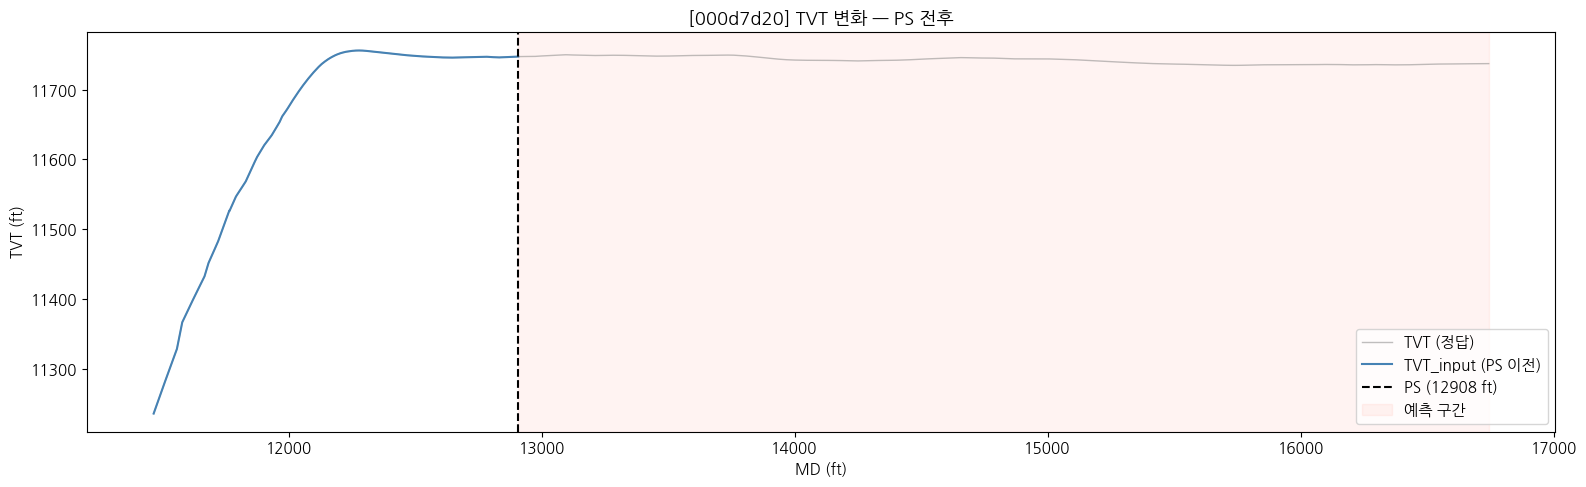

In [9]:
# [8] TVT 및 TVT_input 시각화
fig, ax = plt.subplots()

ax.plot(hw['MD'], hw['TVT'],       color='gray',      linewidth=1,   alpha=0.5, label='TVT (정답)')
ax.plot(hw['MD'], hw['TVT_input'], color='steelblue', linewidth=1.5, label='TVT_input (PS 이전)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')

# 예측 구간 음영
ax.axvspan(ps_md, hw['MD'].max(), alpha=0.07, color='tomato', label='예측 구간')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] TVT 변화 — PS 전후')
ax.legend()
plt.tight_layout()
plt.show()

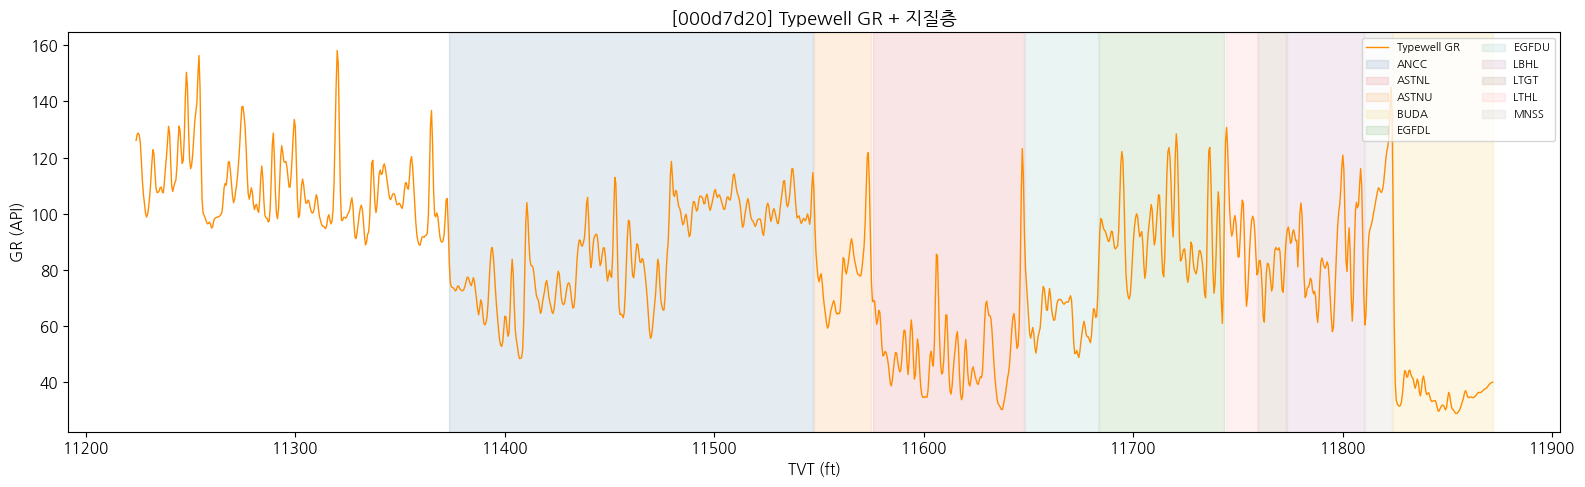

In [10]:
# [9] Typewell GR 및 지질층 시각화
fig, ax = plt.subplots()

ax.plot(tw['TVT'], tw['GR'], color='darkorange', linewidth=1, label='Typewell GR')

# 지질층 경계 표시
geology_colors = {
    'ANCC': '#4e79a7', 'ASTNU': '#f28e2b', 'ASTNL': '#e15759',
    'EGFDU': '#76b7b2', 'EGFDL': '#59a14f', 'BUDA': '#edc948',
    'LBHL': '#b07aa1', 'LTHL': '#ff9da7', 'LTGT': '#9c755f', 'MNSS': '#bab0ac'
}
tw_geo = tw.dropna(subset=['Geology'])
for geo, group in tw_geo.groupby('Geology'):
    color = geology_colors.get(geo, 'gray')
    ax.axvspan(group['TVT'].min(), group['TVT'].max(), alpha=0.15, color=color, label=geo)

ax.set_xlabel('TVT (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] Typewell GR + 지질층')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

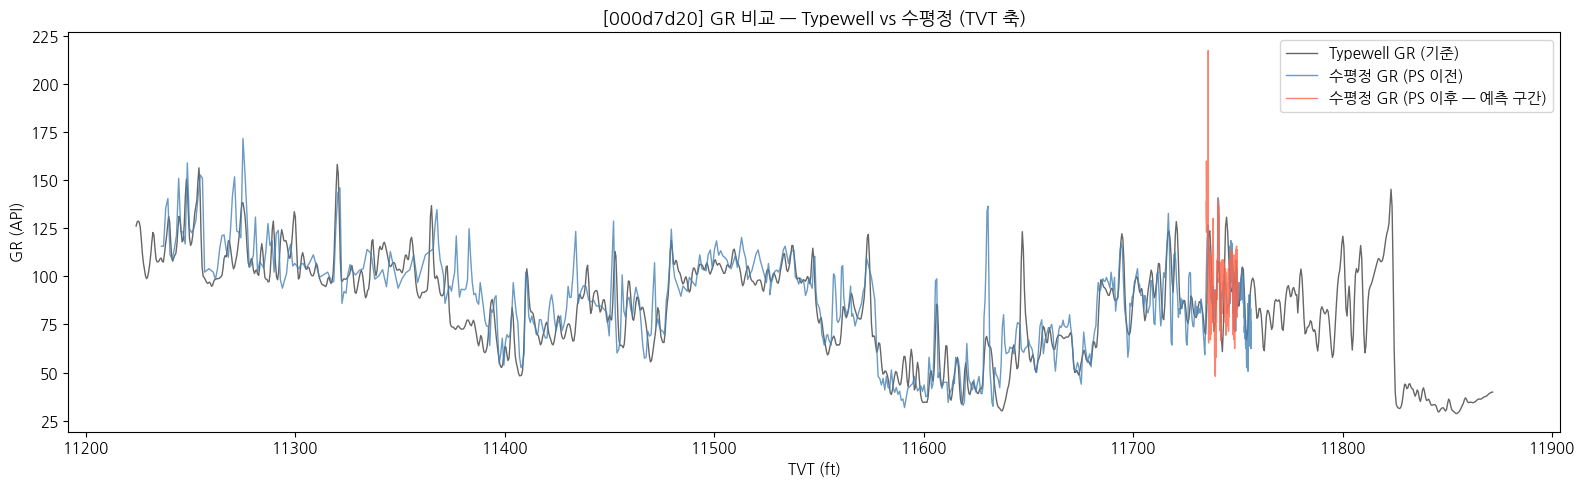

In [11]:
# [10] 수평정 GR vs Typewell GR 비교 (TVT 축 기준)
# 수평정 GR을 TVT 축에 투영해서 Typewell GR과 비교
fig, ax = plt.subplots()

# Typewell
ax.plot(tw['TVT'], tw['GR'],
        color='black', linewidth=1, alpha=0.6, label='Typewell GR (기준)')

# PS 이전 수평정 GR
hw_before = hw[(hw['MD'] <= ps_md) & hw['GR'].notna()]
ax.plot(hw_before['TVT'], hw_before['GR'],
        color='steelblue', linewidth=1, alpha=0.8, label='수평정 GR (PS 이전)')

# PS 이후 수평정 GR
hw_after = hw[(hw['MD'] > ps_md) & hw['GR'].notna()]
ax.plot(hw_after['TVT'], hw_after['GR'],
        color='tomato', linewidth=1, alpha=0.8, label='수평정 GR (PS 이후 — 예측 구간)')

ax.set_xlabel('TVT (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] GR 비교 — Typewell vs 수평정 (TVT 축)')
ax.legend()
plt.tight_layout()
plt.show()

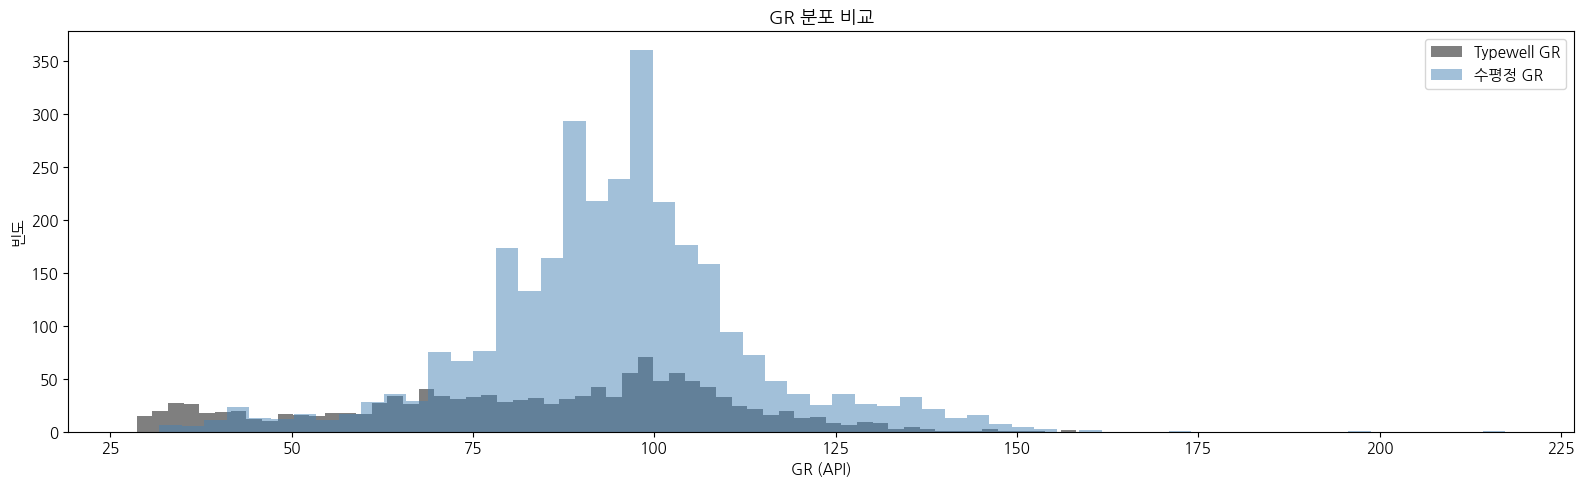

In [12]:
# [11] GR 분포 비교 (히스토그램)
fig, ax = plt.subplots()

ax.hist(tw['GR'],      bins=60, alpha=0.5, color='black',     label='Typewell GR')
ax.hist(hw['GR'].dropna(), bins=60, alpha=0.5, color='steelblue', label='수평정 GR')

ax.set_xlabel('GR (API)')
ax.set_ylabel('빈도')
ax.set_title('GR 분포 비교')
ax.legend()
plt.tight_layout()
plt.show()


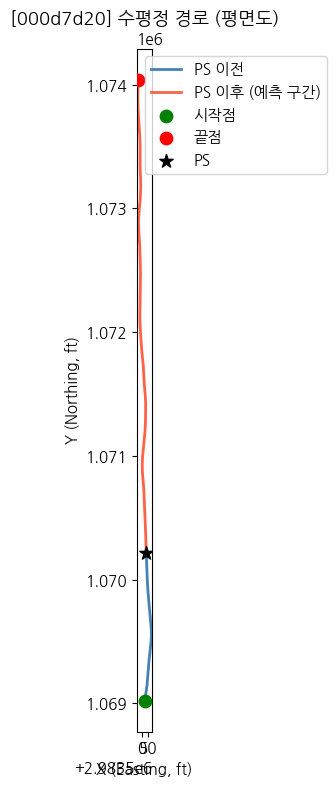

EDA 수행 완료


In [13]:
# [12] 웰 경로 2D 시각화 (X-Y 평면)
fig, ax = plt.subplots(figsize=(8, 8))

before = hw[hw['MD'] <= ps_md]
after  = hw[hw['MD'] >  ps_md]

ax.plot(before['X'], before['Y'], color='steelblue', linewidth=2, label='PS 이전')
ax.plot(after['X'],  after['Y'],  color='tomato',    linewidth=2, label='PS 이후 (예측 구간)')
ax.scatter(hw['X'].iloc[0],  hw['Y'].iloc[0],  color='green', s=80, zorder=5, label='시작점')
ax.scatter(hw['X'].iloc[-1], hw['Y'].iloc[-1], color='red',   s=80, zorder=5, label='끝점')
ax.scatter(before['X'].iloc[-1], before['Y'].iloc[-1],
           color='black', s=100, marker='*', zorder=5, label=f'PS')

ax.set_xlabel('X (Easting, ft)')
ax.set_ylabel('Y (Northing, ft)')
ax.set_title(f'[{WELL_NAME}] 수평정 경로 (평면도)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print('EDA 수행 완료')

## 3주차 전처리

보간 전 GR NaN: 2258
보간 후 GR NaN: 0
이상치 기준값 (99th percentile): 141.7 API
이상치 개수: 53개
처리 후 GR 최대값: 141.7 API


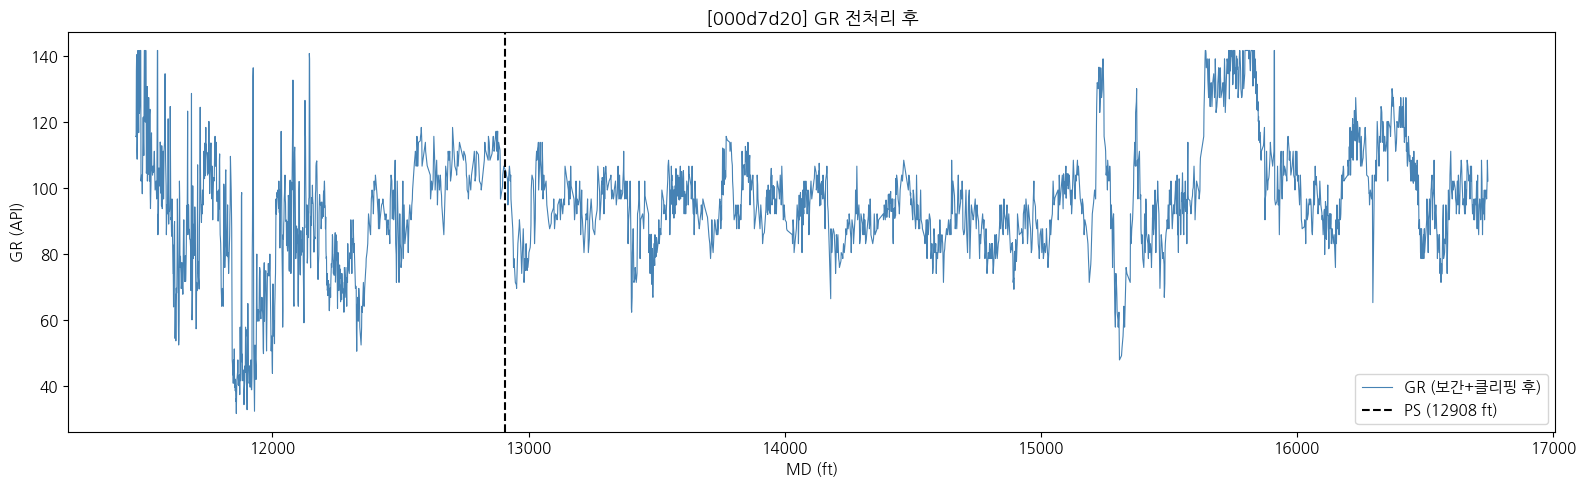

In [14]:
# ── 전처리 1: GR 선형 보간 ──────────────────────────────
print('보간 전 GR NaN:', hw['GR'].isna().sum())

hw['GR'] = hw['GR'].interpolate(method='linear')

# 앞뒤로 채워지지 않은 엣지 케이스 처리 (맨 앞/뒤 NaN)
hw['GR'] = hw['GR'].bfill().ffill()

print('보간 후 GR NaN:', hw['GR'].isna().sum())

# ── 전처리 2: 이상치 제거 ────────────────────────────────
threshold = hw['GR'].quantile(0.99)   # 상위 1% 기준
print(f'이상치 기준값 (99th percentile): {threshold:.1f} API')
print(f'이상치 개수: {(hw["GR"] > threshold).sum()}개')

hw['GR'] = hw['GR'].clip(upper=threshold)

print(f'처리 후 GR 최대값: {hw["GR"].max():.1f} API')

# ── 결과 시각화 ──────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(hw['MD'], hw['GR'], color='steelblue', linewidth=0.8, label='GR (보간+클리핑 후)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1.5, label=f'PS ({ps_md:.0f} ft)')
ax.set_xlabel('MD (ft)')
ax.set_ylabel('GR (API)')
ax.set_title(f'[{WELL_NAME}] GR 전처리 후')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── 전처리 결과 저장 ─────────────────────────────────────
hw.to_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_processed.csv', index=False)
print('저장 완료:', f'{BASE_PATH}/train/{WELL_NAME}__hw_processed.csv')

저장 완료: /content/drive/MyDrive/ROGII/train/000d7d20__hw_processed.csv


In [16]:
# ── Feature Engineering ──────────────────────────────────
import numpy as np

# 1. GR 이동평균 (주변 패턴 파악)
for w in [5, 10, 20]:
    hw[f'GR_ma{w}'] = hw['GR'].rolling(w, center=True, min_periods=1).mean()

# 2. GR 기울기 (GR이 올라가는지 내려가는지)
hw['GR_diff1'] = hw['GR'].diff(1)   # 1칸 차이
hw['GR_diff5'] = hw['GR'].diff(5)   # 5칸 차이
hw['GR_diff1'] = hw['GR_diff1'].fillna(0)
hw['GR_diff5'] = hw['GR_diff5'].fillna(0)

# 3. GR 이동 표준편차 (얼마나 불규칙한지)
hw['GR_std10'] = hw['GR'].rolling(10, center=True, min_periods=1).std().fillna(0)

# 4. Typewell GR 매칭 (현재 TVT 위치에서 Typewell GR이 얼마인지)
#    → 수평정 TVT와 가장 가까운 Typewell TVT를 찾아 GR 가져오기
def match_typewell_gr(tvt_val, tw):
    idx = (tw['TVT'] - tvt_val).abs().idxmin()
    return tw.loc[idx, 'GR']

hw['TW_GR_matched'] = hw['TVT_input'].apply(
    lambda x: match_typewell_gr(x, tw) if pd.notna(x) else np.nan
)
# PS 이후는 TVT_input이 NaN → TVT 정답으로 매칭 (학습 시에만 사용 가능)
mask = hw['TVT_input'].isna()
hw.loc[mask, 'TW_GR_matched'] = hw.loc[mask, 'TVT'].apply(
    lambda x: match_typewell_gr(x, tw)
)

# 5. 수평정 GR - Typewell GR 차이
hw['GR_diff_tw'] = hw['GR'] - hw['TW_GR_matched']

# 6. 지질층 경계까지의 거리
geo_cols = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
for col in geo_cols:
    hw[f'dist_{col}'] = hw['Z'] - hw[col]   # 현재 Z에서 각 지층까지 거리

# ── 피처 확인 ─────────────────────────────────────────────
feature_cols = (
    ['MD', 'X', 'Y', 'Z', 'GR']
    + [f'GR_ma{w}' for w in [5, 10, 20]]
    + ['GR_diff1', 'GR_diff5', 'GR_std10']
    + ['TW_GR_matched', 'GR_diff_tw']
    + [f'dist_{col}' for col in geo_cols]
)

print(f'총 피처 수: {len(feature_cols)}개')
print(hw[feature_cols].head())
print()
print('NaN 확인:')
print(hw[feature_cols].isna().sum())

# ── 저장 ──────────────────────────────────────────────────
hw.to_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_featured.csv', index=False)
print('\n피처 파일 저장 완료')

총 피처 수: 19개
        MD           X           Y        Z          GR      GR_ma5  \
0  11467.0  2983525.16  1069022.09 -9258.57  115.692586  122.241280   
1  11468.0  2983525.18  1069022.30 -9259.55  115.584293  126.781296   
2  11469.0  2983525.20  1069022.52 -9260.52  135.446960  123.679165   
3  11470.0  2983525.22  1069022.73 -9261.50  140.401346  122.296629   
4  11471.0  2983525.25  1069022.95 -9262.47  111.270638  122.047556   

      GR_ma10     GR_ma20   GR_diff1  GR_diff5   GR_std10  TW_GR_matched  \
0  123.679165  122.807854   0.000000       0.0  13.241943         109.45   
1  121.195955  122.817331  -0.108293       0.0  13.314549         107.40   
2  120.216380  122.317606  19.862666       0.0  12.427711         116.27   
3  120.371728  123.807579   4.954386       0.0  11.514211         125.90   
4  122.740121  123.872536 -29.130707       0.0  12.903041         128.65   

   GR_diff_tw  dist_ANCC  dist_ASTNU  dist_ASTNL  dist_EGFDU  dist_EGFDL  \
0    6.242586     137.24    

검증 중 (PS 이전)...
[검증] RMSE: 187.4874 ft
예측 중 (PS 이후)...
[테스트] RMSE: 261.8548 ft


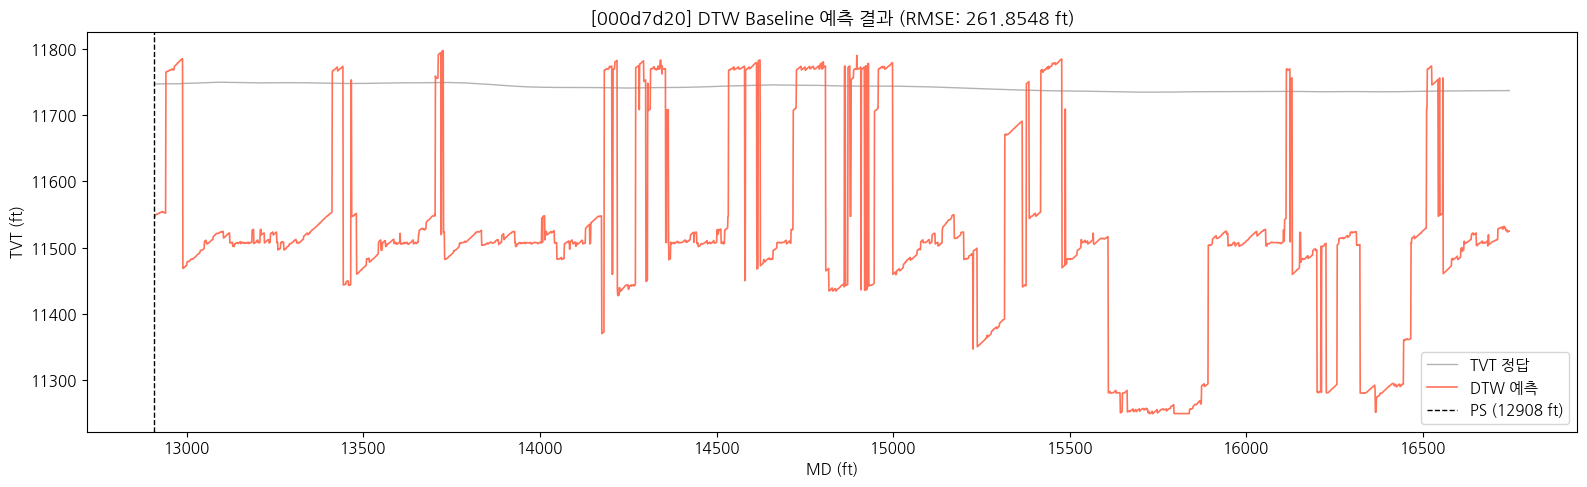

In [17]:
# ── DTW Baseline ─────────────────────────────────────────
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import mean_squared_error
import numpy as np

# 데이터 준비
hw_before = hw[hw['MD'] <= ps_md].copy().reset_index(drop=True)
hw_after  = hw[hw['MD'] >  ps_md].copy().reset_index(drop=True)

tw_gr  = tw['GR'].values
tw_tvt = tw['TVT'].values

# ── 핵심 함수: GR 윈도우 매칭으로 TVT 예측 ──────────────
# 아이디어: 현재 지점 주변 GR 패턴을 Typewell GR 전체에서 슬라이딩하며
#           MSE가 가장 낮은 위치를 찾아 그 TVT를 예측값으로 사용

def predict_by_gr_matching(hw_gr, tw_gr, tw_tvt, window=100):
    n_tw   = len(tw_gr)
    n_pred = len(hw_gr)
    predictions = np.zeros(n_pred)

    for i in range(n_pred):
        # 현재 지점 주변 GR 윈도우 추출
        half  = window // 2
        s     = max(0, i - half)
        e     = min(n_pred, i + half)
        query = hw_gr[s:e]
        q_len = len(query)

        if q_len < 2 or q_len > n_tw:
            predictions[i] = tw_tvt[n_tw // 2]
            continue

        # Typewell 전체를 같은 길이의 윈도우로 쪼개서 MSE 비교
        tw_windows = sliding_window_view(tw_gr, q_len)          # 벡터화 슬라이딩
        mses       = np.mean((tw_windows - query) ** 2, axis=1) # 각 위치 MSE
        best_j     = np.argmin(mses)                            # 가장 유사한 위치

        # 해당 위치의 TVT를 예측값으로
        center = min(best_j + q_len // 2, n_tw - 1)
        predictions[i] = tw_tvt[center]

    return predictions

# ── 검증: PS 이전 구간으로 모델 성능 확인 ────────────────
print('검증 중 (PS 이전)...')
val_gr  = hw_before['GR'].values
val_tvt = hw_before['TVT'].values

val_pred = predict_by_gr_matching(val_gr, tw_gr, tw_tvt, window=100)
val_rmse = np.sqrt(mean_squared_error(val_tvt, val_pred))
print(f'[검증] RMSE: {val_rmse:.4f} ft')

# ── 예측: PS 이후 구간 ────────────────────────────────────
print('예측 중 (PS 이후)...')
pred_gr  = hw_after['GR'].values
pred_tvt = predict_by_gr_matching(pred_gr, tw_gr, tw_tvt, window=100)

hw_after['TVT_pred_dtw'] = pred_tvt

# PS 이후 실제 정답이 있으니까 RMSE 계산 가능
test_rmse = np.sqrt(mean_squared_error(hw_after['TVT'].values, pred_tvt))
print(f'[테스트] RMSE: {test_rmse:.4f} ft')

# ── 시각화 ───────────────────────────────────────────────
fig, ax = plt.subplots()

ax.plot(hw_after['MD'], hw_after['TVT'],          color='gray',    linewidth=1,   alpha=0.6, label='TVT 정답')
ax.plot(hw_after['MD'], hw_after['TVT_pred_dtw'], color='tomato',  linewidth=1.2, alpha=0.9, label='DTW 예측')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] DTW Baseline 예측 결과 (RMSE: {test_rmse:.4f} ft)')
ax.legend()
plt.tight_layout()
plt.show()

PS 직전 TVT    : 11747.37 ft
Typewell 앵커  : index 1047, TVT 11747.45 ft
DTW v2 RMSE (raw)    : 46.9564 ft
DTW v2 RMSE (smooth) : 45.5885 ft

DTW v2 RMSE : 46.9564 ft


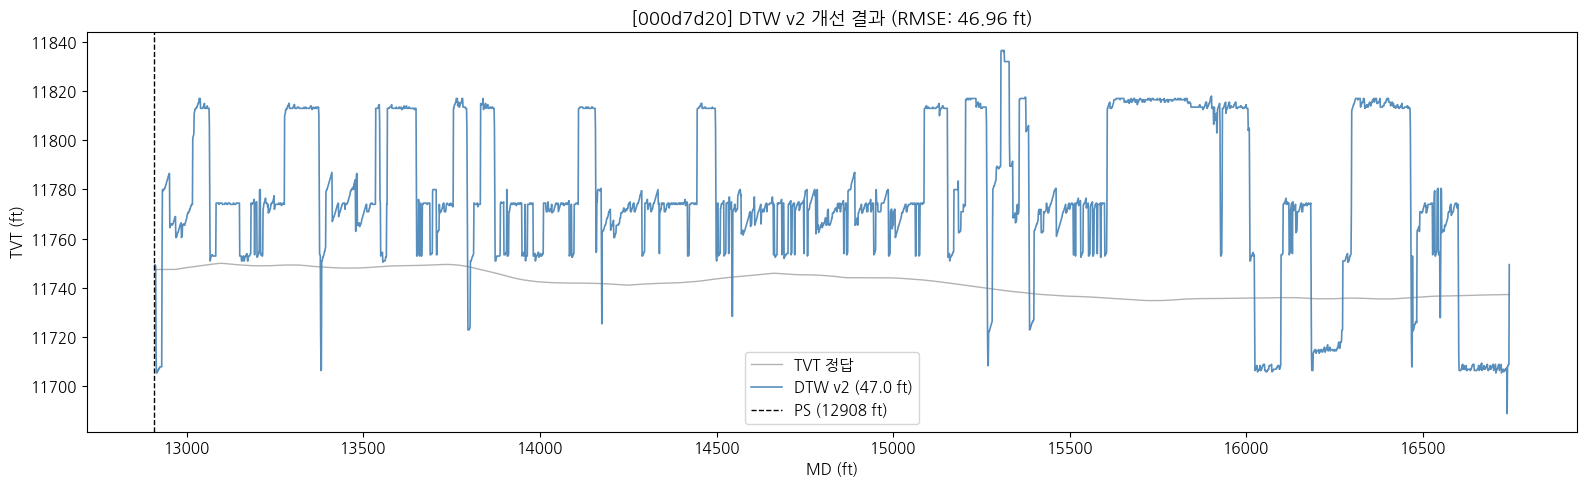

In [18]:
# ── DTW 개선 v2: 앵커 + 연속성 제약 ────────────────────
from sklearn.metrics import mean_squared_error
import numpy as np

tw_gr  = tw['GR'].values
tw_tvt = tw['TVT'].values
n_tw   = len(tw_gr)

hw_before = hw[hw['MD'] <= ps_md].copy().reset_index(drop=True)
hw_after  = hw[hw['MD'] >  ps_md].copy().reset_index(drop=True)

# ── Step 1: 앵커 설정 ─────────────────────────────────────
last_tvt   = hw_before['TVT_input'].dropna().iloc[-1]
anchor_idx = int((np.abs(tw_tvt - last_tvt)).argmin())

print(f'PS 직전 TVT    : {last_tvt:.2f} ft')
print(f'Typewell 앵커  : index {anchor_idx}, TVT {tw_tvt[anchor_idx]:.2f} ft')

# ── Step 2: 연속성 제약을 가진 순차 매칭 ─────────────────
GR_WINDOW    = 30
SEARCH_RANGE = 80

hw_after_gr    = hw_after['GR'].values
n_pred         = len(hw_after_gr)
predictions    = []
current_tw_idx = anchor_idx

for i in range(n_pred):
    half  = GR_WINDOW // 2
    s     = max(0, i - half)
    e     = min(n_pred, i + half)
    query = hw_after_gr[s:e]
    q_len = len(query)

    tw_s = max(0, current_tw_idx - SEARCH_RANGE)
    tw_e = min(n_tw - q_len, current_tw_idx + SEARCH_RANGE)

    best_mse = np.inf
    best_idx = current_tw_idx

    for j in range(tw_s, tw_e):
        segment = tw_gr[j : j + q_len]
        if len(segment) == q_len:
            mse = np.mean((query - segment) ** 2)
            if mse < best_mse:
                best_mse = mse
                best_idx = j + q_len // 2

    current_tw_idx = best_idx
    predictions.append(tw_tvt[min(best_idx, n_tw - 1)])

hw_after['TVT_pred_dtw_v2'] = predictions

# 후처리: 이동평균으로 튀는 값 완화
hw_after['TVT_pred_dtw_v2_smooth'] = (
    hw_after['TVT_pred_dtw_v2']
    .rolling(window=20, center=True, min_periods=1)
    .mean()
)

rmse_raw    = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2']))
rmse_smooth = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2_smooth']))

print(f'DTW v2 RMSE (raw)    : {rmse_raw:.4f} ft')
print(f'DTW v2 RMSE (smooth) : {rmse_smooth:.4f} ft')

# ── Step 3: 평가 ──────────────────────────────────────────
rmse_v2 = np.sqrt(mean_squared_error(hw_after['TVT'], hw_after['TVT_pred_dtw_v2']))
print(f'\nDTW v2 RMSE : {rmse_v2:.4f} ft')

# ── Step 4: 시각화 ────────────────────────────────────────
fig, ax = plt.subplots()

ax.plot(hw_after['MD'], hw_after['TVT'],             color='gray',      linewidth=1,   alpha=0.6, label='TVT 정답')
ax.plot(hw_after['MD'], hw_after['TVT_pred_dtw_v2'], color='steelblue', linewidth=1.2, alpha=0.9, label=f'DTW v2 ({rmse_v2:.1f} ft)')
ax.axvline(ps_md, color='black', linestyle='--', linewidth=1, label=f'PS ({ps_md:.0f} ft)')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] DTW v2 개선 결과 (RMSE: {rmse_v2:.2f} ft)')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
last_tvt = hw_before['TVT_input'].dropna().iloc[-1]
rmse_const = np.sqrt(mean_squared_error(hw_after['TVT'], np.full(len(hw_after), last_tvt)))
print(f'Constant baseline RMSE: {rmse_const:.4f} ft')

Constant baseline RMSE: 7.4544 ft


## 4주차 모델 학습

In [20]:
hw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_featured.csv')
print(hw.columns.tolist())
print(hw.shape)

['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'GR_ma5', 'GR_ma10', 'GR_ma20', 'GR_diff1', 'GR_diff5', 'GR_std10', 'TW_GR_matched', 'GR_diff_tw', 'dist_ANCC', 'dist_ASTNU', 'dist_ASTNL', 'dist_EGFDU', 'dist_EGFDL', 'dist_BUDA']
(5278, 27)


XGBoost RMSE  : 28.6555 ft
Constant RMSE : 7.4544 ft
개선 여부     : ✗ 미개선


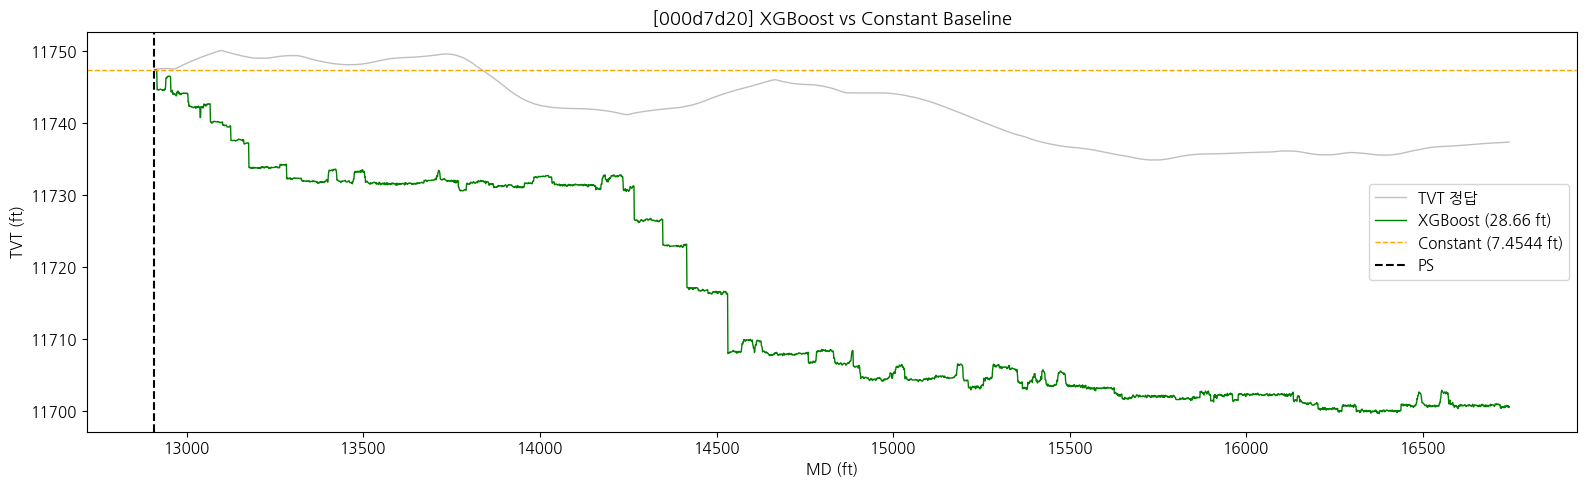

In [21]:
# [XGBoost]
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

BASE_PATH = '/content/drive/MyDrive/ROGII'
WELL_NAME = '000d7d20'

hw = pd.read_csv(f'{BASE_PATH}/train/{WELL_NAME}__hw_featured.csv')

ps_idx    = hw['TVT_input'].last_valid_index()
hw_before = hw.loc[:ps_idx].copy()
hw_after  = hw.loc[ps_idx+1:].copy()

# 테스트에서도 쓸 수 있는 피처만 (제출용 기준)
feature_cols = [
    'GR', 'GR_ma5', 'GR_ma10', 'GR_ma20',
    'GR_diff1', 'GR_diff5', 'GR_std10',
    'TW_GR_matched', 'GR_diff_tw',
    'MD', 'X', 'Y', 'Z'
]

# 학습: PS 이전 (TVT 알려진 구간, GR NaN 제외)
train_df = hw_before.dropna(subset=feature_cols + ['TVT'])
X_train  = train_df[feature_cols]
y_train  = train_df['TVT']

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

# 예측: PS 이후
test_df = hw_after.dropna(subset=feature_cols)
preds   = model.predict(test_df[feature_cols])

rmse_xgb   = np.sqrt(mean_squared_error(test_df['TVT'], preds))
rmse_const = 7.4544  # 상수 baseline 참고용
print(f'XGBoost RMSE  : {rmse_xgb:.4f} ft')
print(f'Constant RMSE : {rmse_const:.4f} ft')
print(f'개선 여부     : {"✓ 개선" if rmse_xgb < rmse_const else "✗ 미개선"}')

# 시각화
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hw_after['MD'], hw_after['TVT'],
        color='gray', alpha=0.5, linewidth=1, label='TVT 정답')
ax.plot(test_df['MD'], preds,
        color='green', linewidth=1, label=f'XGBoost ({rmse_xgb:.2f} ft)')
ax.axhline(hw_before['TVT_input'].dropna().iloc[-1],
           color='orange', linestyle='--', linewidth=1, label=f'Constant ({rmse_const} ft)')
ax.axvline(hw.loc[ps_idx, 'MD'], color='black', linestyle='--', label='PS')
ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] XGBoost vs Constant Baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# PS 직전 평탄 구간만 학습에 사용
TRAIN_WINDOW = 700 # 값 조정하며 최적 RMSE 결정 (=700)

train_df = hw_before.tail(TRAIN_WINDOW).dropna(subset=feature_cols + ['TVT'])
X_train  = train_df[feature_cols]
y_train  = train_df['TVT']

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

test_df = hw_after.dropna(subset=feature_cols)
preds   = model.predict(test_df[feature_cols])

rmse_xgb = np.sqrt(mean_squared_error(test_df['TVT'], preds))
print(f'XGBoost RMSE (window={TRAIN_WINDOW}): {rmse_xgb:.4f} ft')

XGBoost RMSE (window=700): 6.9215 ft


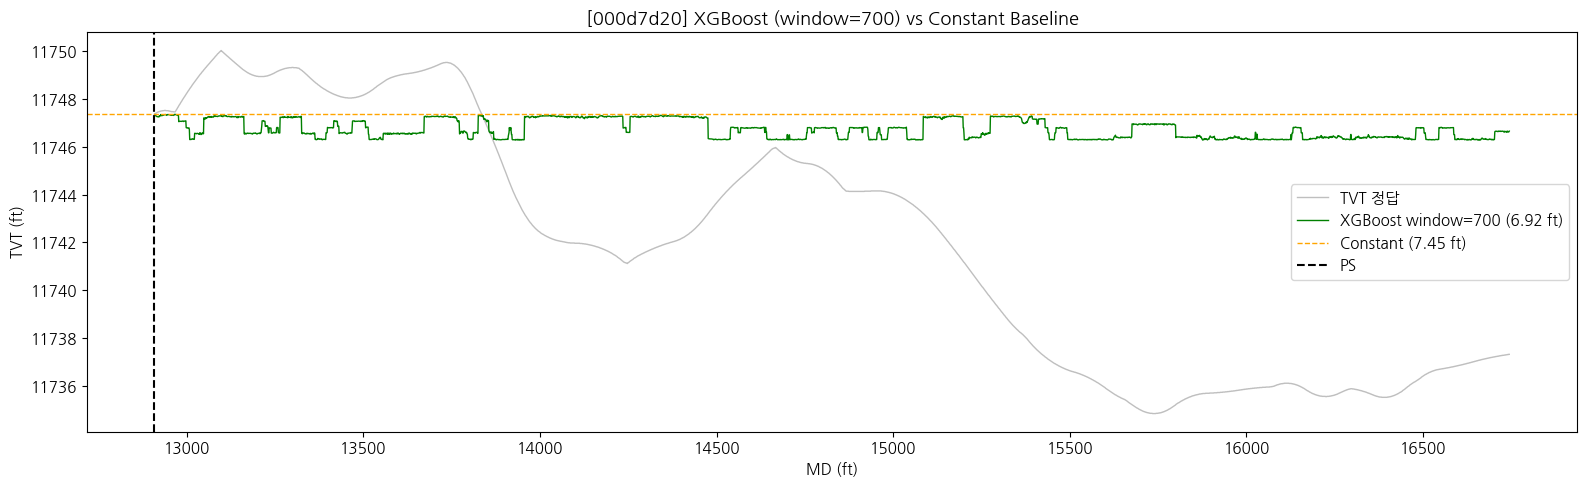

In [29]:
# [XGBoost 시각화: window=700]
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(hw_after['MD'], hw_after['TVT'],
        color='gray', alpha=0.5, linewidth=1, label='TVT 정답')
ax.plot(test_df['MD'], preds,
        color='green', linewidth=1, label=f'XGBoost window=700 ({rmse_xgb:.2f} ft)')
ax.axhline(hw_before['TVT_input'].dropna().iloc[-1],
           color='orange', linestyle='--', linewidth=1, label=f'Constant (7.45 ft)')
ax.axvline(hw.loc[ps_idx, 'MD'], color='black', linestyle='--', label='PS')

ax.set_xlabel('MD (ft)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'[{WELL_NAME}] XGBoost (window=700) vs Constant Baseline')
ax.legend()
plt.tight_layout()
plt.show()

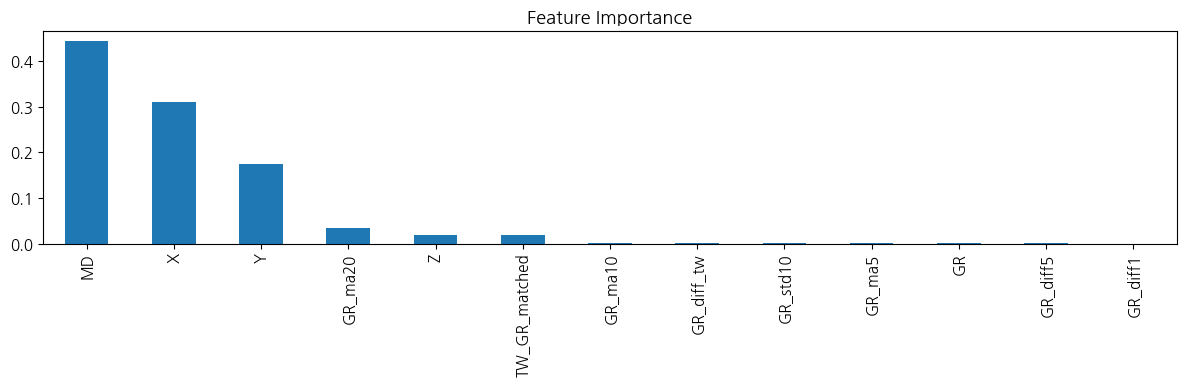

In [30]:
# 피처 중요도 확인
import pandas as pd
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(12, 4), title='Feature Importance')
plt.tight_layout()
plt.show()

In [31]:
# [멀티 웰 XGBoost 파이프라인]
import pandas as pd
import numpy as np
import glob, os
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

TRAIN_WINDOW = 700

feature_cols = [
    'GR', 'GR_ma5', 'GR_ma10', 'GR_ma20',
    'GR_diff1', 'GR_diff5', 'GR_std10',
    'TW_GR_matched', 'GR_diff_tw',
    'MD_rel'  # 절대 MD 대신 PS 기준 상대값 사용
]

def preprocess(hw):
    hw = hw.copy()
    hw['GR'] = hw['GR'].interpolate(method='linear').bfill().ffill()
    hw['GR'] = hw['GR'].clip(upper=hw['GR'].quantile(0.99))
    return hw

def add_features(hw, tw):
    hw = hw.copy()
    # GR 이동통계
    for w in [5, 10, 20]:
        hw[f'GR_ma{w}'] = hw['GR'].rolling(w, center=True, min_periods=1).mean()
    hw['GR_diff1'] = hw['GR'].diff(1).fillna(0)
    hw['GR_diff5'] = hw['GR'].diff(5).fillna(0)
    hw['GR_std10'] = hw['GR'].rolling(10, center=True, min_periods=1).std().fillna(0)

    # Typewell GR 매칭
    tw_tvt = tw['TVT'].values
    tw_gr  = tw['GR'].values
    def match_gr(tvt):
        if pd.isna(tvt): return np.nan
        return tw_gr[np.argmin(np.abs(tw_tvt - tvt))]
    hw['TW_GR_matched'] = hw['TVT_input'].apply(match_gr)
    hw['TW_GR_matched'] = hw['TW_GR_matched'].interpolate().bfill().ffill()
    hw['GR_diff_tw'] = hw['GR'] - hw['TW_GR_matched']

    # PS 기준 상대 MD
    ps_idx = hw['TVT_input'].last_valid_index()
    hw['MD_rel'] = hw['MD'] - hw.loc[ps_idx, 'MD']

    return hw, ps_idx

# ── 전체 웰 로드 & 학습 데이터 수집 ──
hw_files = sorted(glob.glob(f'{BASE_PATH}/train/*__horizontal_well.csv'))
print(f'총 웰 수: {len(hw_files)}')

all_train = []
skipped   = 0

for hw_path in hw_files:
    well = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    tw_path = hw_path.replace('__horizontal_well.csv', '__typewell.csv')
    if not os.path.exists(tw_path):
        skipped += 1
        continue
    try:
        hw = preprocess(pd.read_csv(hw_path))
        tw = pd.read_csv(tw_path)
        hw, ps_idx = add_features(hw, tw)
        chunk = hw.loc[:ps_idx].tail(TRAIN_WINDOW).dropna(subset=feature_cols + ['TVT'])
        if len(chunk) >= 50:
            all_train.append(chunk)
    except Exception as e:
        skipped += 1

print(f'학습 웰 수  : {len(all_train)}')
print(f'스킵된 웰  : {skipped}')

train_df = pd.concat(all_train, ignore_index=True)
print(f'총 학습 행 : {len(train_df)}')

# ── XGBoost 학습 ──
model_multi = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model_multi.fit(train_df[feature_cols], train_df['TVT'])
print('학습 완료')

총 웰 수: 773
학습 웰 수  : 773
스킵된 웰  : 0
총 학습 행 : 541100
학습 완료


In [32]:
# [멀티 웰 평가]
import random

# 평가할 웰 목록 (000d7d20 포함 + 랜덤 4개)
eval_wells = ['000d7d20'] + random.sample(
    [os.path.basename(f).replace('__horizontal_well.csv','') for f in hw_files
     if '000d7d20' not in f],
    4
)

results = []

for well in eval_wells:
    hw_path = f'{BASE_PATH}/train/{well}__horizontal_well.csv'
    tw_path = f'{BASE_PATH}/train/{well}__typewell.csv'

    try:
        hw = preprocess(pd.read_csv(hw_path))
        tw = pd.read_csv(tw_path)
        hw, ps_idx = add_features(hw, tw)

        hw_before = hw.loc[:ps_idx]
        hw_after  = hw.loc[ps_idx+1:]

        test_df = hw_after.dropna(subset=feature_cols + ['TVT'])
        if len(test_df) < 10:
            continue

        preds      = model_multi.predict(test_df[feature_cols])
        rmse_multi = np.sqrt(mean_squared_error(test_df['TVT'], preds))

        last_tvt   = hw_before['TVT_input'].dropna().iloc[-1]
        rmse_const = np.sqrt(mean_squared_error(test_df['TVT'],
                             np.full(len(test_df), last_tvt)))

        results.append({
            'well': well,
            'RMSE_multi': round(rmse_multi, 4),
            'RMSE_const': round(rmse_const, 4),
            'improvement': '✓' if rmse_multi < rmse_const else '✗'
        })
    except Exception as e:
        print(f'{well} 오류: {e}')

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))
print(f'\n평균 RMSE (multi) : {result_df["RMSE_multi"].mean():.4f} ft')
print(f'평균 RMSE (const) : {result_df["RMSE_const"].mean():.4f} ft')

    well  RMSE_multi  RMSE_const improvement
000d7d20    330.4802      7.4544           ✗
1e30dedf   1216.4481     12.1371           ✗
4ed93db6    352.1244      9.1343           ✗
0e5e560d    445.0795     10.2939           ✗
995ff498    351.9650      8.3437           ✗

평균 RMSE (multi) : 539.2194 ft
평균 RMSE (const) : 9.4727 ft


In [35]:
# [Delta 예측 버전]
all_train_delta = []

for hw_path in hw_files:
    well = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    tw_path = hw_path.replace('__horizontal_well.csv', '__typewell.csv')
    if not os.path.exists(tw_path):
        continue
    try:
        hw = preprocess(pd.read_csv(hw_path))
        tw = pd.read_csv(tw_path)
        hw, ps_idx = add_features(hw, tw)

        hw_before = hw.loc[:ps_idx].copy()
        last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]

        # TVT_delta를 슬라이싱 이후에 hw_before에 직접 추가
        hw_before['TVT_delta'] = hw_before['TVT'] - last_tvt

        chunk = hw_before.tail(TRAIN_WINDOW).dropna(subset=feature_cols + ['TVT_delta'])
        if len(chunk) >= 50:
            all_train_delta.append(chunk)
    except Exception as e:
        print(f'{well} 오류: {e}')

print(f'수집된 웰 수: {len(all_train_delta)}')

if len(all_train_delta) > 0:
    train_delta_df = pd.concat(all_train_delta, ignore_index=True)
    print(f'총 학습 행: {len(train_delta_df)}')
    print(f'TVT_delta 범위: {train_delta_df["TVT_delta"].min():.1f} ~ {train_delta_df["TVT_delta"].max():.1f} ft')

    model_delta = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model_delta.fit(train_delta_df[feature_cols], train_delta_df['TVT_delta'])
    print('Delta 모델 학습 완료')

수집된 웰 수: 773
총 학습 행: 541100
TVT_delta 범위: -491.5 ~ 45.8 ft
Delta 모델 학습 완료


In [36]:
# [Delta 모델 평가]
results_delta = []

for well in eval_wells:  # 아까 랜덤 선택한 5개 웰 재사용
    hw_path = f'{BASE_PATH}/train/{well}__horizontal_well.csv'
    tw_path = f'{BASE_PATH}/train/{well}__typewell.csv'
    try:
        hw = preprocess(pd.read_csv(hw_path))
        tw = pd.read_csv(tw_path)
        hw, ps_idx = add_features(hw, tw)

        hw_before = hw.loc[:ps_idx]
        hw_after  = hw.loc[ps_idx+1:]
        last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]

        test_df = hw_after.dropna(subset=feature_cols + ['TVT'])
        if len(test_df) < 10:
            continue

        delta_preds = model_delta.predict(test_df[feature_cols])
        tvt_preds   = last_tvt + delta_preds  # delta → 절대값 복원

        rmse_delta = np.sqrt(mean_squared_error(test_df['TVT'], tvt_preds))
        rmse_const = np.sqrt(mean_squared_error(test_df['TVT'],
                             np.full(len(test_df), last_tvt)))

        results_delta.append({
            'well': well,
            'RMSE_delta': round(rmse_delta, 4),
            'RMSE_const': round(rmse_const, 4),
            'improvement': '✓' if rmse_delta < rmse_const else '✗'
        })
    except Exception as e:
        print(f'{well} 오류: {e}')

result_df2 = pd.DataFrame(results_delta)
print(result_df2.to_string(index=False))
print(f'\n평균 RMSE (delta) : {result_df2["RMSE_delta"].mean():.4f} ft')
print(f'평균 RMSE (const) : {result_df2["RMSE_const"].mean():.4f} ft')

    well  RMSE_delta  RMSE_const improvement
000d7d20      7.9415      7.4544           ✗
1e30dedf     13.8373     12.1371           ✗
4ed93db6      9.4708      9.1343           ✗
0e5e560d     10.8907     10.2939           ✗
995ff498      8.4457      8.3437           ✗

평균 RMSE (delta) : 10.1172 ft
평균 RMSE (const) : 9.4727 ft


In [39]:
# [전체 웰 평가]
all_results = []

for hw_path in hw_files:
    well = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    tw_path = hw_path.replace('__horizontal_well.csv', '__typewell.csv')
    if not os.path.exists(tw_path):
        continue
    try:
        hw = preprocess(pd.read_csv(hw_path))
        tw = pd.read_csv(tw_path)
        hw, ps_idx = add_features(hw, tw)

        hw_before = hw.loc[:ps_idx]
        hw_after  = hw.loc[ps_idx+1:]
        last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]

        test_df = hw_after.dropna(subset=feature_cols + ['TVT'])
        if len(test_df) < 10:
            continue

        # Constant
        rmse_const = np.sqrt(mean_squared_error(test_df['TVT'],
                             np.full(len(test_df), last_tvt)))

        # Delta 모델
        delta_preds = model_delta.predict(test_df[feature_cols])
        rmse_delta  = np.sqrt(mean_squared_error(test_df['TVT'],
                              last_tvt + delta_preds))

        all_results.append({
            'well': well,
            'RMSE_const': rmse_const,
            'RMSE_delta': rmse_delta
        })
    except:
        pass

res_df = pd.DataFrame(all_results)
print(f'평가 웰 수       : {len(res_df)}')
print(f'Constant 평균   : {res_df["RMSE_const"].mean():.4f} ft')
print(f'Delta 평균      : {res_df["RMSE_delta"].mean():.4f} ft')
print(f'Delta 승리 웰   : {(res_df["RMSE_delta"] < res_df["RMSE_const"]).sum()} / {len(res_df)}')
print(f'\nConstant 중앙값 : {res_df["RMSE_const"].median():.4f} ft')
print(f'Delta 중앙값    : {res_df["RMSE_delta"].median():.4f} ft')

평가 웰 수       : 773
Constant 평균   : 12.8125 ft
Delta 평균      : 13.2789 ft
Delta 승리 웰   : 238 / 773

Constant 중앙값 : 10.6651 ft
Delta 중앙값    : 11.0151 ft


### **여기서부터 Kaggle 노트북에서 Submission 수행**
...했지만 제출 순위에서 뭔가 단단히 잘못되었음을 깨닫고 개선 방향 구상

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train 웰 수: 773
예시: ['/content/drive/MyDrive/ROGII/train/000d7d20__horizontal_well.csv', '/content/drive/MyDrive/ROGII/train/00bbac68__horizontal_well.csv']
평가 웰 수: 773
방법                     단순 평균        가중 평균
----------------------------------------------------
Constant            12.8125      13.0883
Linear              33.7847      35.1460
Adaptive            31.2222      32.3349

Linear < Constant:   117/773 웰
Adaptive < Constant: 35/773 웰


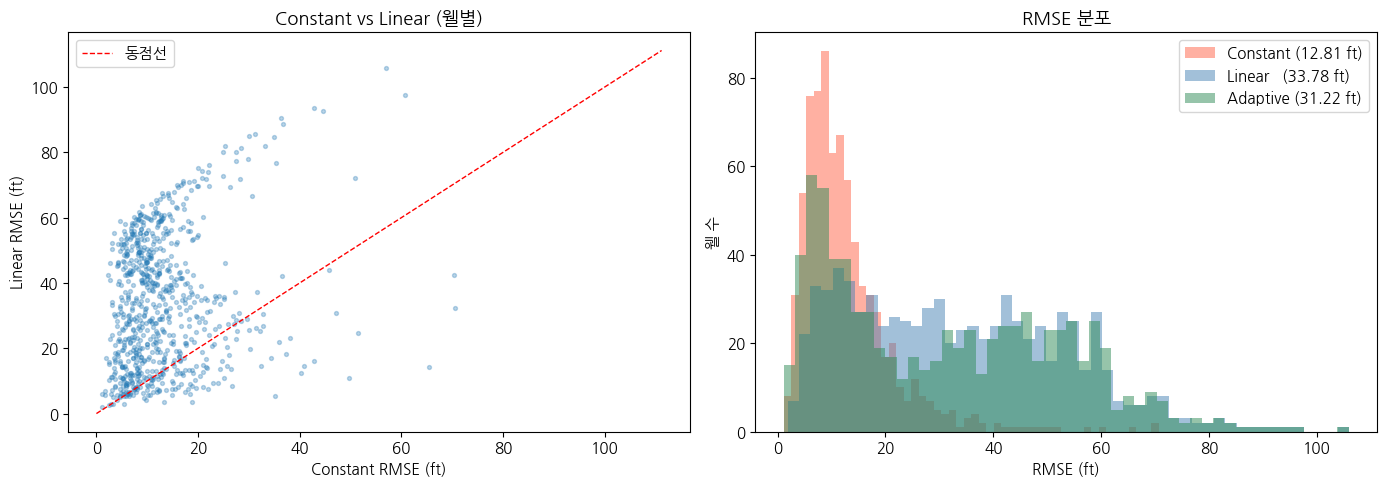

In [43]:
"""
Week 4: Linear Trend Extrapolation — 전체 웰 평가 + Kaggle 제출 코드
폴더 구조: ROGII/train/{well_id}__horizontal_well.csv
                        {well_id}__typewell.csv
"""

# ════════════════════════════════════════════════
# 셀 1. 라이브러리 & 경로 설정
# ════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import glob, os, warnings
warnings.filterwarnings('ignore')

# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/ROGII/train'
TEST_PATH  = '/content/drive/MyDrive/ROGII/test'   # test 폴더 있으면 사용

# 파일 목록 확인
hw_files = sorted(glob.glob(f'{TRAIN_PATH}/*__horizontal_well.csv'))
print(f"train 웰 수: {len(hw_files)}")
print("예시:", hw_files[:2])


# ════════════════════════════════════════════════
# 셀 2. 데이터 로드 함수 & 예측 함수 정의
# ════════════════════════════════════════════════

def load_well(hw_path):
    """파일 하나 로드 + well_id 추가"""
    well_id = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    hw = pd.read_csv(hw_path)
    hw['well'] = well_id
    return hw, well_id

def load_typewell(well_id, folder):
    """해당 웰의 typewell 로드"""
    tw_path = f'{folder}/{well_id}__typewell.csv'
    if os.path.exists(tw_path):
        return pd.read_csv(tw_path)
    return None

def preprocess(hw):
    hw = hw.copy()
    hw['GR'] = hw['GR'].interpolate(method='linear').bfill().ffill()
    hw['GR'] = hw['GR'].clip(upper=hw['GR'].quantile(0.99))
    return hw

def predict_constant(hw):
    """PS 직전 마지막 TVT를 이후 전체에 사용"""
    ps_idx   = hw['TVT_input'].last_valid_index()
    hw_after = hw.loc[ps_idx + 1:]
    last_tvt = hw.loc[:ps_idx]['TVT_input'].dropna().iloc[-1]
    return pd.Series(last_tvt, index=hw_after.index), hw_after

def predict_linear(hw, N=200, max_drift=60):
    """PS 직전 N행 선형 회귀 → MD 기반 외삽"""
    ps_idx    = hw['TVT_input'].last_valid_index()
    hw_after  = hw.loc[ps_idx + 1:]
    last_tvt  = hw.loc[:ps_idx]['TVT_input'].dropna().iloc[-1]

    recent = hw.loc[:ps_idx].tail(N).dropna(subset=['TVT_input'])
    if len(recent) < 20:
        return pd.Series(last_tvt, index=hw_after.index), hw_after

    lr = LinearRegression()
    lr.fit(recent[['MD']], recent['TVT_input'])
    preds = lr.predict(hw_after[['MD']])
    preds = np.clip(preds, last_tvt - max_drift, last_tvt + max_drift)
    return pd.Series(preds, index=hw_after.index), hw_after

def predict_adaptive(hw, N=200, max_drift=60, slope_threshold=0.01):
    """기울기 작으면 상수, 크면 선형 외삽"""
    ps_idx    = hw['TVT_input'].last_valid_index()
    hw_after  = hw.loc[ps_idx + 1:]
    last_tvt  = hw.loc[:ps_idx]['TVT_input'].dropna().iloc[-1]

    recent = hw.loc[:ps_idx].tail(N).dropna(subset=['TVT_input'])
    if len(recent) < 20:
        return pd.Series(last_tvt, index=hw_after.index), hw_after

    lr = LinearRegression()
    lr.fit(recent[['MD']], recent['TVT_input'])
    slope = abs(lr.coef_[0])

    if slope < slope_threshold:
        return pd.Series(last_tvt, index=hw_after.index), hw_after

    preds = lr.predict(hw_after[['MD']])
    preds = np.clip(preds, last_tvt - max_drift, last_tvt + max_drift)
    return pd.Series(preds, index=hw_after.index), hw_after


# ════════════════════════════════════════════════
# 셀 3. 전체 train 웰 평가
# ════════════════════════════════════════════════

results = []

for hw_path in hw_files:
    try:
        hw, well_id = load_well(hw_path)
        hw = preprocess(hw)

        ps_idx = hw['TVT_input'].last_valid_index()
        if ps_idx is None:
            continue

        hw_after = hw.loc[ps_idx + 1:]
        true_tvt = hw_after['TVT'].dropna()
        if len(true_tvt) == 0:
            continue

        pred_const, _ = predict_constant(hw)
        pred_lin,   _ = predict_linear(hw)
        pred_adap,  _ = predict_adaptive(hw)

        rmse_const = np.sqrt(mean_squared_error(true_tvt, pred_const.loc[true_tvt.index]))
        rmse_lin   = np.sqrt(mean_squared_error(true_tvt, pred_lin.loc[true_tvt.index]))
        rmse_adap  = np.sqrt(mean_squared_error(true_tvt, pred_adap.loc[true_tvt.index]))

        results.append({
            'well':       well_id,
            'n_rows':     len(true_tvt),
            'rmse_const': rmse_const,
            'rmse_lin':   rmse_lin,
            'rmse_adap':  rmse_adap,
        })

    except Exception as e:
        print(f"[SKIP] {well_id}: {e}")

df = pd.DataFrame(results)

# 가중 평균 (행 수 기준)
w = df['n_rows']
wavg = lambda col: (df[col] * w).sum() / w.sum()

print("=" * 52)
print(f"평가 웰 수: {len(df)}")
print(f"{'방법':<15} {'단순 평균':>12} {'가중 평균':>12}")
print("-" * 52)
for col, label in [('rmse_const','Constant'), ('rmse_lin','Linear'), ('rmse_adap','Adaptive')]:
    print(f"{label:<15} {df[col].mean():>11.4f}  {wavg(col):>11.4f}")
print("=" * 52)
print(f"\nLinear < Constant:   {(df['rmse_lin'] < df['rmse_const']).sum()}/{len(df)} 웰")
print(f"Adaptive < Constant: {(df['rmse_adap'] < df['rmse_const']).sum()}/{len(df)} 웰")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df['rmse_const'], df['rmse_lin'], alpha=0.3, s=8)
lim = max(df['rmse_const'].max(), df['rmse_lin'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='동점선')
ax.set_xlabel('Constant RMSE (ft)'); ax.set_ylabel('Linear RMSE (ft)')
ax.set_title('Constant vs Linear (웰별)'); ax.legend()

ax = axes[1]
ax.hist(df['rmse_const'], bins=50, alpha=0.5, label=f'Constant ({df["rmse_const"].mean():.2f} ft)', color='tomato')
ax.hist(df['rmse_lin'],   bins=50, alpha=0.5, label=f'Linear   ({df["rmse_lin"].mean():.2f} ft)',   color='steelblue')
ax.hist(df['rmse_adap'],  bins=50, alpha=0.5, label=f'Adaptive ({df["rmse_adap"].mean():.2f} ft)',  color='seagreen')
ax.set_xlabel('RMSE (ft)'); ax.set_ylabel('웰 수')
ax.set_title('RMSE 분포'); ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ROGII/week4_eval.png', dpi=150)
plt.show()

In [44]:
"""
Week 4: Particle Filter TVT Prediction
GR + Typewell 활용 → Constant(12.81 ft)를 넘는 것이 목표

알고리즘:
1. PS 직전 GR 패턴으로 Typewell 위치 앵커링 (1회)
2. 이후 각 행마다 GR 관측값으로 파티클 가중치 업데이트
3. 가중 평균 TVT = 예측값

코랩 실행 순서:
셀1 → 셀2(함수) → 셀3(단일 웰 테스트) → 셀4(전체 평가) → 셀5(Kaggle 코드)
"""

# ════════════════════════════════════════════════
# 셀 1. 라이브러리 & 경로
# ════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/ROGII/train'

hw_files = sorted(glob.glob(f'{TRAIN_PATH}/*__horizontal_well.csv'))
print(f"train 웰 수: {len(hw_files)}")


# ════════════════════════════════════════════════
# 셀 2. 함수 정의
# ════════════════════════════════════════════════

def preprocess(hw):
    hw = hw.copy()
    hw['GR'] = hw['GR'].interpolate(method='linear').bfill().ffill()
    hw['GR'] = hw['GR'].clip(upper=hw['GR'].quantile(0.99))
    return hw

def load_well_pair(hw_path):
    well_id = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    hw = pd.read_csv(hw_path)
    tw_path = hw_path.replace('__horizontal_well.csv', '__typewell.csv')
    tw = pd.read_csv(tw_path) if os.path.exists(tw_path) else None
    return hw, tw, well_id

def predict_constant(hw):
    ps_idx   = hw['TVT_input'].last_valid_index()
    hw_after = hw.loc[ps_idx + 1:]
    last_tvt = hw.loc[:ps_idx]['TVT_input'].dropna().iloc[-1]
    return pd.Series(last_tvt, index=hw_after.index), hw_after


def predict_particle_filter(hw, tw,
                             N_anchor=50,
                             n_particles=200,
                             sigma_motion=0.5,
                             sigma_obs=15.0,
                             max_drift=50):
    """
    Particle Filter for TVT prediction using GR + Typewell

    Parameters
    ----------
    N_anchor     : PS 직전 GR 윈도우 크기 (앵커 매칭용)
    n_particles  : 파티클 수 (많을수록 정확, 느림)
    sigma_motion : 한 행당 TVT 변화량 std (ft) — 수평정이므로 작게
    sigma_obs    : GR 관측 노이즈 std (API units)
    max_drift    : last_tvt 기준 예측 허용 범위 (ft)
    """
    if tw is None:
        return predict_constant(hw)[0], hw.loc[hw['TVT_input'].last_valid_index() + 1:]

    ps_idx   = hw['TVT_input'].last_valid_index()
    hw_before = hw.loc[:ps_idx]
    hw_after  = hw.loc[ps_idx + 1:]
    last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]

    if len(hw_after) == 0:
        return pd.Series(dtype=float), hw_after

    tw_gr  = tw['GR'].values.astype(float)
    tw_tvt = tw['TVT'].values.astype(float)
    n_tw   = len(tw)

    # ── Step 1: GR 캘리브레이션 (Typewell GR → 이 웰 GR 스케일로 변환) ──
    ps_before_tvt = hw_before['TVT_input'].dropna()
    tw_gr_cal = tw_gr.copy()
    if len(ps_before_tvt) > 10:
        tw_gr_at_hw = np.array([
            tw_gr[int(np.abs(tw_tvt - v).argmin())]
            for v in ps_before_tvt.values
        ])
        hw_gr_known = hw_before.loc[ps_before_tvt.index, 'GR'].values
        valid = ~np.isnan(tw_gr_at_hw) & ~np.isnan(hw_gr_known)
        if valid.sum() > 5:
            std_tw = np.std(tw_gr_at_hw[valid]) + 1e-8
            std_hw = np.std(hw_gr_known[valid])
            gain   = std_hw / std_tw
            offset = np.mean(hw_gr_known[valid]) - gain * np.mean(tw_gr_at_hw[valid])
            tw_gr_cal = gain * tw_gr + offset

    # ── Step 2: PS 앵커 (TVT 기반 초기 위치 + GR 윈도우 정밀 매칭) ──
    tvt_anchor_idx = int(np.abs(tw_tvt - last_tvt).argmin())

    hw_anc_gr = hw_before['GR'].values[-N_anchor:]
    w = len(hw_anc_gr)
    SEARCH = 150
    tw_s = max(0, tvt_anchor_idx - SEARCH)
    tw_e = min(n_tw - w, tvt_anchor_idx + SEARCH)

    mse_list = []
    for j in range(tw_s, tw_e + 1):
        cand = tw_gr_cal[j:j + w]
        mse_list.append(np.mean((cand - hw_anc_gr) ** 2) if len(cand) == w else np.inf)

    best_start  = tw_s + int(np.argmin(mse_list))
    anchor_idx  = min(best_start + w - 1, n_tw - 1)

    # ── Step 3: 파티클 초기화 ──
    spread = 30
    particle_idx = np.clip(
        anchor_idx + np.random.randint(-spread, spread + 1, size=n_particles),
        0, n_tw - 1
    )
    weights = np.ones(n_particles) / n_particles

    # ── Step 4: 필터 루프 ──
    predictions = []
    hw_after_gr = hw_after['GR'].values

    for i in range(len(hw_after)):
        gr_obs = hw_after_gr[i]
        if np.isnan(gr_obs):
            gr_obs = float(tw_gr_cal[particle_idx].mean())

        # Motion: 파티클 이동 (수평정 → sigma_motion 작게)
        motion = (np.random.randn(n_particles) * sigma_motion).astype(int)
        particle_idx = np.clip(particle_idx + motion, 0, n_tw - 1)

        # Likelihood: 관측 GR vs Typewell GR
        tw_gr_at_p   = tw_gr_cal[particle_idx]
        log_lik      = -((tw_gr_at_p - gr_obs) ** 2) / (2 * sigma_obs ** 2)

        # 가중치 업데이트 (log-space로 수치 안정성)
        log_w = np.log(weights + 1e-300) + log_lik
        log_w -= log_w.max()
        weights = np.exp(log_w)
        w_sum = weights.sum()
        if w_sum < 1e-300:
            weights = np.ones(n_particles) / n_particles
        else:
            weights /= w_sum

        # 예측: 가중 평균 TVT
        pred_tvt = float(np.sum(tw_tvt[particle_idx] * weights))
        pred_tvt = np.clip(pred_tvt, last_tvt - max_drift, last_tvt + max_drift)
        predictions.append(pred_tvt)

        # Resampling (Effective Sample Size 기준)
        ess = 1.0 / (np.sum(weights ** 2) + 1e-300)
        if ess < n_particles * 0.5:
            cumsum  = np.cumsum(weights)
            u       = (np.arange(n_particles) + np.random.uniform()) / n_particles
            indices = np.clip(np.searchsorted(cumsum, u), 0, n_particles - 1)
            particle_idx = particle_idx[indices]
            weights = np.ones(n_particles) / n_particles

    return pd.Series(predictions, index=hw_after.index), hw_after



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train 웰 수: 773


In [47]:
# 파라미터 보수적으로 수정
def predict_pf_conservative(hw, tw):
    return predict_particle_filter(
        hw, tw,
        sigma_motion=0.1,   # 거의 안 움직임
        sigma_obs=30.0,     # GR에 덜 민감
        max_drift=10,       # ±10 ft 이상 못 감
        n_particles=200
    )

# 이걸로 셀 3 재실행
pred_pf, _ = predict_pf_conservative(hw, tw)

웰: 000d7d20
Constant       : 7.4544 ft
Particle Filter: 6.0231 ft


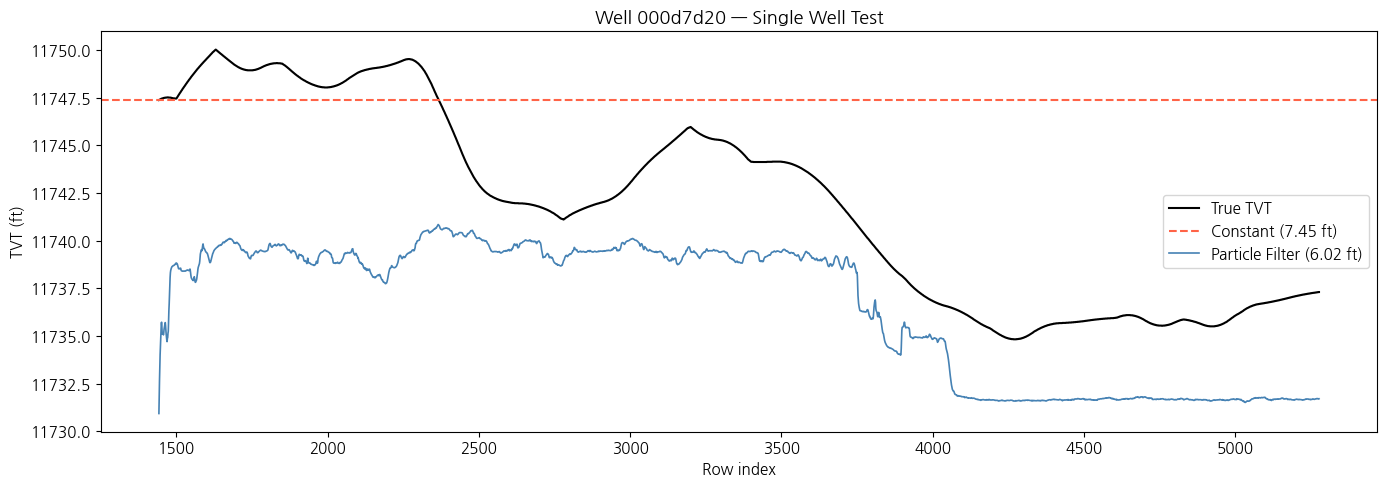

In [48]:
# ════════════════════════════════════════════════
# 셀 3. 단일 웰 테스트 (000d7d20)
# ════════════════════════════════════════════════

TEST_WELL = '000d7d20'
hw_path = f'{TRAIN_PATH}/{TEST_WELL}__horizontal_well.csv'

hw, tw, wid = load_well_pair(hw_path)
hw = preprocess(hw)

ps_idx   = hw['TVT_input'].last_valid_index()
hw_after = hw.loc[ps_idx + 1:]
true_tvt = hw_after['TVT'].dropna()

pred_const, _ = predict_constant(hw)
pred_pf, _    = predict_particle_filter(hw, tw)

from sklearn.metrics import mean_squared_error
rmse_const = np.sqrt(mean_squared_error(true_tvt, pred_const.loc[true_tvt.index]))
rmse_pf    = np.sqrt(mean_squared_error(true_tvt, pred_pf.loc[true_tvt.index]))

print(f"웰: {TEST_WELL}")
print(f"Constant       : {rmse_const:.4f} ft")
print(f"Particle Filter: {rmse_pf:.4f} ft")

# 시각화
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hw_after.index, true_tvt, label='True TVT', color='black', lw=1.5)
ax.axhline(pred_const.iloc[0], label=f'Constant ({rmse_const:.2f} ft)', color='tomato', ls='--')
ax.plot(hw_after.index, pred_pf, label=f'Particle Filter ({rmse_pf:.2f} ft)', color='steelblue', lw=1.2)
ax.set_xlabel('Row index'); ax.set_ylabel('TVT (ft)')
ax.set_title(f'Well {TEST_WELL} — Single Well Test')
ax.legend(); plt.tight_layout(); plt.show()

[50/773] 완료...
[100/773] 완료...
[150/773] 완료...
[200/773] 완료...
[250/773] 완료...
[300/773] 완료...
[350/773] 완료...
[400/773] 완료...
[450/773] 완료...
[500/773] 완료...
[550/773] 완료...
[600/773] 완료...
[650/773] 완료...
[700/773] 완료...
[750/773] 완료...

평가 웰 수: 773
방법                        단순 평균      가중 평균
----------------------------------------------------
Constant                12.8125     13.0883
Particle Filter         28.8180     29.0115

PF < Constant: 150/773 웰


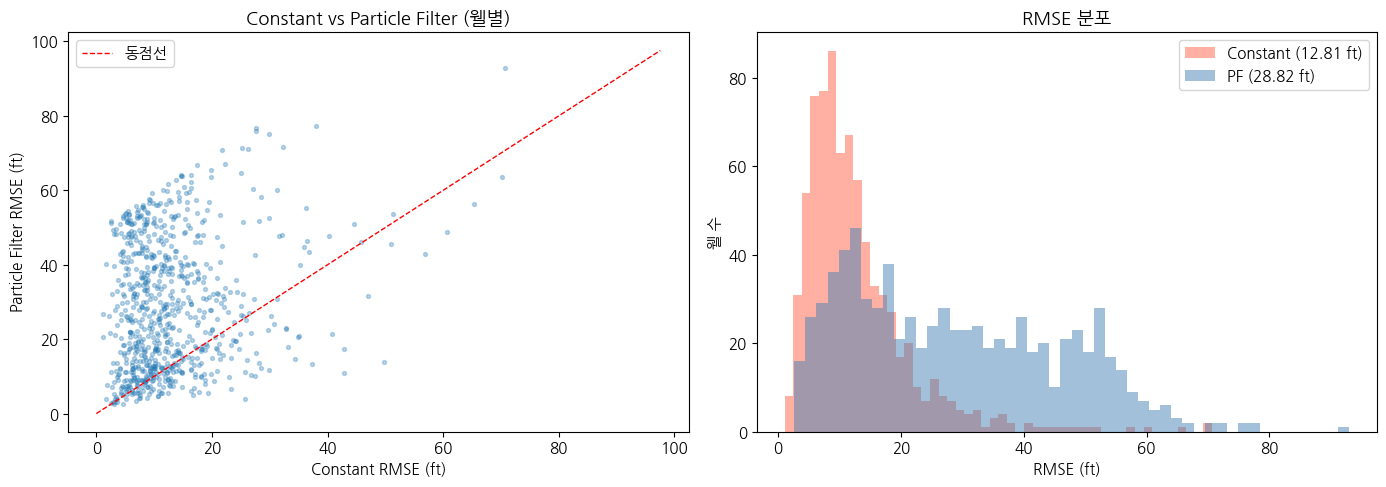

In [49]:
# ════════════════════════════════════════════════
# 셀 4. 전체 773웰 평가 (시간 걸림 — ~10분)
# ════════════════════════════════════════════════

from sklearn.metrics import mean_squared_error

results = []
N_TOTAL = len(hw_files)

for i, hw_path in enumerate(hw_files):
    try:
        hw, tw, well_id = load_well_pair(hw_path)
        hw = preprocess(hw)

        ps_idx   = hw['TVT_input'].last_valid_index()
        if ps_idx is None:
            continue

        hw_after = hw.loc[ps_idx + 1:]
        true_tvt = hw_after['TVT'].dropna()
        if len(true_tvt) == 0:
            continue

        pred_const, _ = predict_constant(hw)
        pred_pf, _    = predict_particle_filter(hw, tw)

        rmse_const = np.sqrt(mean_squared_error(true_tvt, pred_const.loc[true_tvt.index]))

        # Particle Filter: tw 없는 웰은 constant fallback
        pf_vals = pred_pf.loc[true_tvt.index] if tw is not None else pred_const.loc[true_tvt.index]
        rmse_pf = np.sqrt(mean_squared_error(true_tvt, pf_vals))

        results.append({
            'well': well_id, 'n_rows': len(true_tvt),
            'rmse_const': rmse_const, 'rmse_pf': rmse_pf,
        })

        if (i + 1) % 50 == 0:
            print(f"[{i+1}/{N_TOTAL}] 완료...")

    except Exception as e:
        print(f"[SKIP] {well_id}: {e}")

df = pd.DataFrame(results)
w  = df['n_rows']

print("\n" + "=" * 52)
print(f"평가 웰 수: {len(df)}")
print(f"{'방법':<20} {'단순 평균':>10} {'가중 평균':>10}")
print("-" * 52)
for col, label in [('rmse_const', 'Constant'), ('rmse_pf', 'Particle Filter')]:
    simple = df[col].mean()
    weighted = (df[col] * w).sum() / w.sum()
    print(f"{label:<20} {simple:>10.4f}  {weighted:>10.4f}")
print("=" * 52)
print(f"\nPF < Constant: {(df['rmse_pf'] < df['rmse_const']).sum()}/{len(df)} 웰")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df['rmse_const'], df['rmse_pf'], alpha=0.3, s=8)
lim = max(df['rmse_const'].max(), df['rmse_pf'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='동점선')
ax.set_xlabel('Constant RMSE (ft)'); ax.set_ylabel('Particle Filter RMSE (ft)')
ax.set_title('Constant vs Particle Filter (웰별)'); ax.legend()

ax = axes[1]
ax.hist(df['rmse_const'], bins=50, alpha=0.5,
        label=f'Constant ({df["rmse_const"].mean():.2f} ft)', color='tomato')
ax.hist(df['rmse_pf'], bins=50, alpha=0.5,
        label=f'PF ({df["rmse_pf"].mean():.2f} ft)', color='steelblue')
ax.set_xlabel('RMSE (ft)'); ax.set_ylabel('웰 수')
ax.set_title('RMSE 분포'); ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ROGII/week4_pf_eval.png', dpi=150)
plt.show()

In [50]:
def predict_z_based(hw):
    ps_idx    = hw['TVT_input'].last_valid_index()
    hw_before = hw.loc[:ps_idx]
    hw_after  = hw.loc[ps_idx + 1:]
    last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]
    z_ps      = hw.loc[ps_idx, 'Z']
    pred_tvt  = last_tvt + (hw_after['Z'] - z_ps)
    return pd.Series(pred_tvt.values, index=hw_after.index)

# 단일 웰 테스트
pred_z, _ = predict_z_based(hw), None  # hw는 000d7d20 그대로
true_tvt  = hw.loc[hw['TVT_input'].last_valid_index()+1:]['TVT'].dropna()
pred_z    = predict_z_based(hw)
rmse_z    = np.sqrt(mean_squared_error(true_tvt, pred_z.loc[true_tvt.index]))
print(f"Z-based: {rmse_z:.4f} ft  (Constant: 7.4544 ft)")

Z-based: 89.0440 ft  (Constant: 7.4544 ft)


In [51]:
ps_idx = hw['TVT_input'].last_valid_index()
hw_after = hw.loc[ps_idx+1:]
print("Z post-PS 변화량:", hw_after['Z'].iloc[-1] - hw_after['Z'].iloc[0])
print("TVT post-PS 변화량:", hw_after['TVT'].iloc[-1] - hw_after['TVT'].iloc[0])
print("Z-TVT 상관관계:", hw_after[['Z','TVT']].corr().iloc[0,1])

Z post-PS 변화량: -161.76000000000022
TVT post-PS 변화량: -9.30999999999949
Z-TVT 상관관계: 0.7344493221795979


In [52]:
def predict_z_scaled(hw, N=300, max_drift=40):
    ps_idx    = hw['TVT_input'].last_valid_index()
    hw_before = hw.loc[:ps_idx]
    hw_after  = hw.loc[ps_idx + 1:]
    last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]
    z_ps      = hw.loc[ps_idx, 'Z']

    # Pre-PS에서 dTVT/dZ 비율 추정
    recent = hw_before.tail(N).dropna(subset=['TVT_input'])
    dz   = recent['Z'].diff().dropna()
    dtvt = recent['TVT_input'].diff().dropna()
    idx  = dz.index.intersection(dtvt.index)
    mask = abs(dz.loc[idx]) > 0.01
    if mask.sum() < 5:
        return pd.Series(last_tvt, index=hw_after.index)

    scale = (dtvt.loc[idx][mask] / dz.loc[idx][mask]).median()

    preds = last_tvt + scale * (hw_after['Z'] - z_ps)
    preds = np.clip(preds, last_tvt - max_drift, last_tvt + max_drift)
    return pd.Series(preds.values, index=hw_after.index)

# 단일 웰 테스트
pred_z_scaled = predict_z_scaled(hw)
rmse_zs = np.sqrt(mean_squared_error(true_tvt, pred_z_scaled.loc[true_tvt.index]))
print(f"Z-scaled: {rmse_zs:.4f} ft  (Constant: 7.4544 ft)")

Z-scaled: 23.8487 ft  (Constant: 7.4544 ft)


In [53]:
"""
Week 4: 나머지 피처 분석 (ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA)
목표: 이 피처들이 TVT 변화를 예측하는 데 쓸 수 있는지 확인

실행 순서: 셀 1 → 2 → 3 → 4 → 5
"""

# ════════════════════════════════════════════════
# 셀 1. 단일 웰 피처 기초 분석 (000d7d20)
# ════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, warnings
warnings.filterwarnings('ignore')

TRAIN_PATH = '/content/drive/MyDrive/ROGII/train'
EXTRA_COLS = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']

TEST_WELL  = '000d7d20'
hw_path    = f'{TRAIN_PATH}/{TEST_WELL}__horizontal_well.csv'
hw = pd.read_csv(hw_path)
tw_path = hw_path.replace('__horizontal_well.csv', '__typewell.csv')
tw = pd.read_csv(tw_path)

ps_idx    = hw['TVT_input'].last_valid_index()
hw_before = hw.loc[:ps_idx]
hw_after  = hw.loc[ps_idx + 1:]

print("=" * 60)
print(f"웰: {TEST_WELL}")
print(f"PS 이전 행 수: {len(hw_before)},  PS 이후 행 수: {len(hw_after)}")
print("=" * 60)

# NaN 비율
print("\n[NaN 비율]")
for col in EXTRA_COLS:
    if col in hw.columns:
        nan_pct = hw[col].isna().mean() * 100
        nan_before = hw_before[col].isna().mean() * 100
        nan_after  = hw_after[col].isna().mean() * 100
        print(f"  {col:<10} 전체={nan_pct:.1f}%  PS전={nan_before:.1f}%  PS후={nan_after:.1f}%")
    else:
        print(f"  {col:<10} 컬럼 없음")

# Typewell에 있는 피처
print("\n[Typewell 컬럼]")
print(tw.columns.tolist())


# ════════════════════════════════════════════════
# 셀 2. TVT와의 상관관계 (PS 이전 구간)
# ════════════════════════════════════════════════

print("\n[PS 이전 구간 — TVT_input과의 상관관계]")
for col in EXTRA_COLS:
    if col in hw_before.columns:
        valid = hw_before[['TVT_input', col]].dropna()
        if len(valid) > 10:
            corr = valid['TVT_input'].corr(valid[col])
            print(f"  {col:<10} corr={corr:+.4f}  (n={len(valid)})")

print("\n[PS 이후 구간 — TVT와의 상관관계]")
for col in EXTRA_COLS:
    if col in hw_after.columns:
        valid = hw_after[['TVT', col]].dropna()
        if len(valid) > 10:
            corr = valid['TVT'].corr(valid[col])
            print(f"  {col:<10} corr={corr:+.4f}  (n={len(valid)})")

웰: 000d7d20
PS 이전 행 수: 1442,  PS 이후 행 수: 3836

[NaN 비율]
  ANCC       전체=0.0%  PS전=0.0%  PS후=0.0%
  ASTNU      전체=0.0%  PS전=0.0%  PS후=0.0%
  ASTNL      전체=0.0%  PS전=0.0%  PS후=0.0%
  EGFDU      전체=0.0%  PS전=0.0%  PS후=0.0%
  EGFDL      전체=0.0%  PS전=0.0%  PS후=0.0%
  BUDA       전체=0.0%  PS전=0.0%  PS후=0.0%

[Typewell 컬럼]
['TVT', 'GR', 'Geology']

[PS 이전 구간 — TVT_input과의 상관관계]
  ANCC       corr=+0.7198  (n=1442)
  ASTNU      corr=+0.7198  (n=1442)
  ASTNL      corr=+0.7198  (n=1442)
  EGFDU      corr=+0.7198  (n=1442)
  EGFDL      corr=+0.7198  (n=1442)
  BUDA       corr=+0.7198  (n=1442)

[PS 이후 구간 — TVT와의 상관관계]
  ANCC       corr=-0.9073  (n=3836)
  ASTNU      corr=-0.9073  (n=3836)
  ASTNL      corr=-0.9073  (n=3836)
  EGFDU      corr=-0.9073  (n=3836)
  EGFDL      corr=-0.9073  (n=3836)
  BUDA       corr=-0.9073  (n=3836)


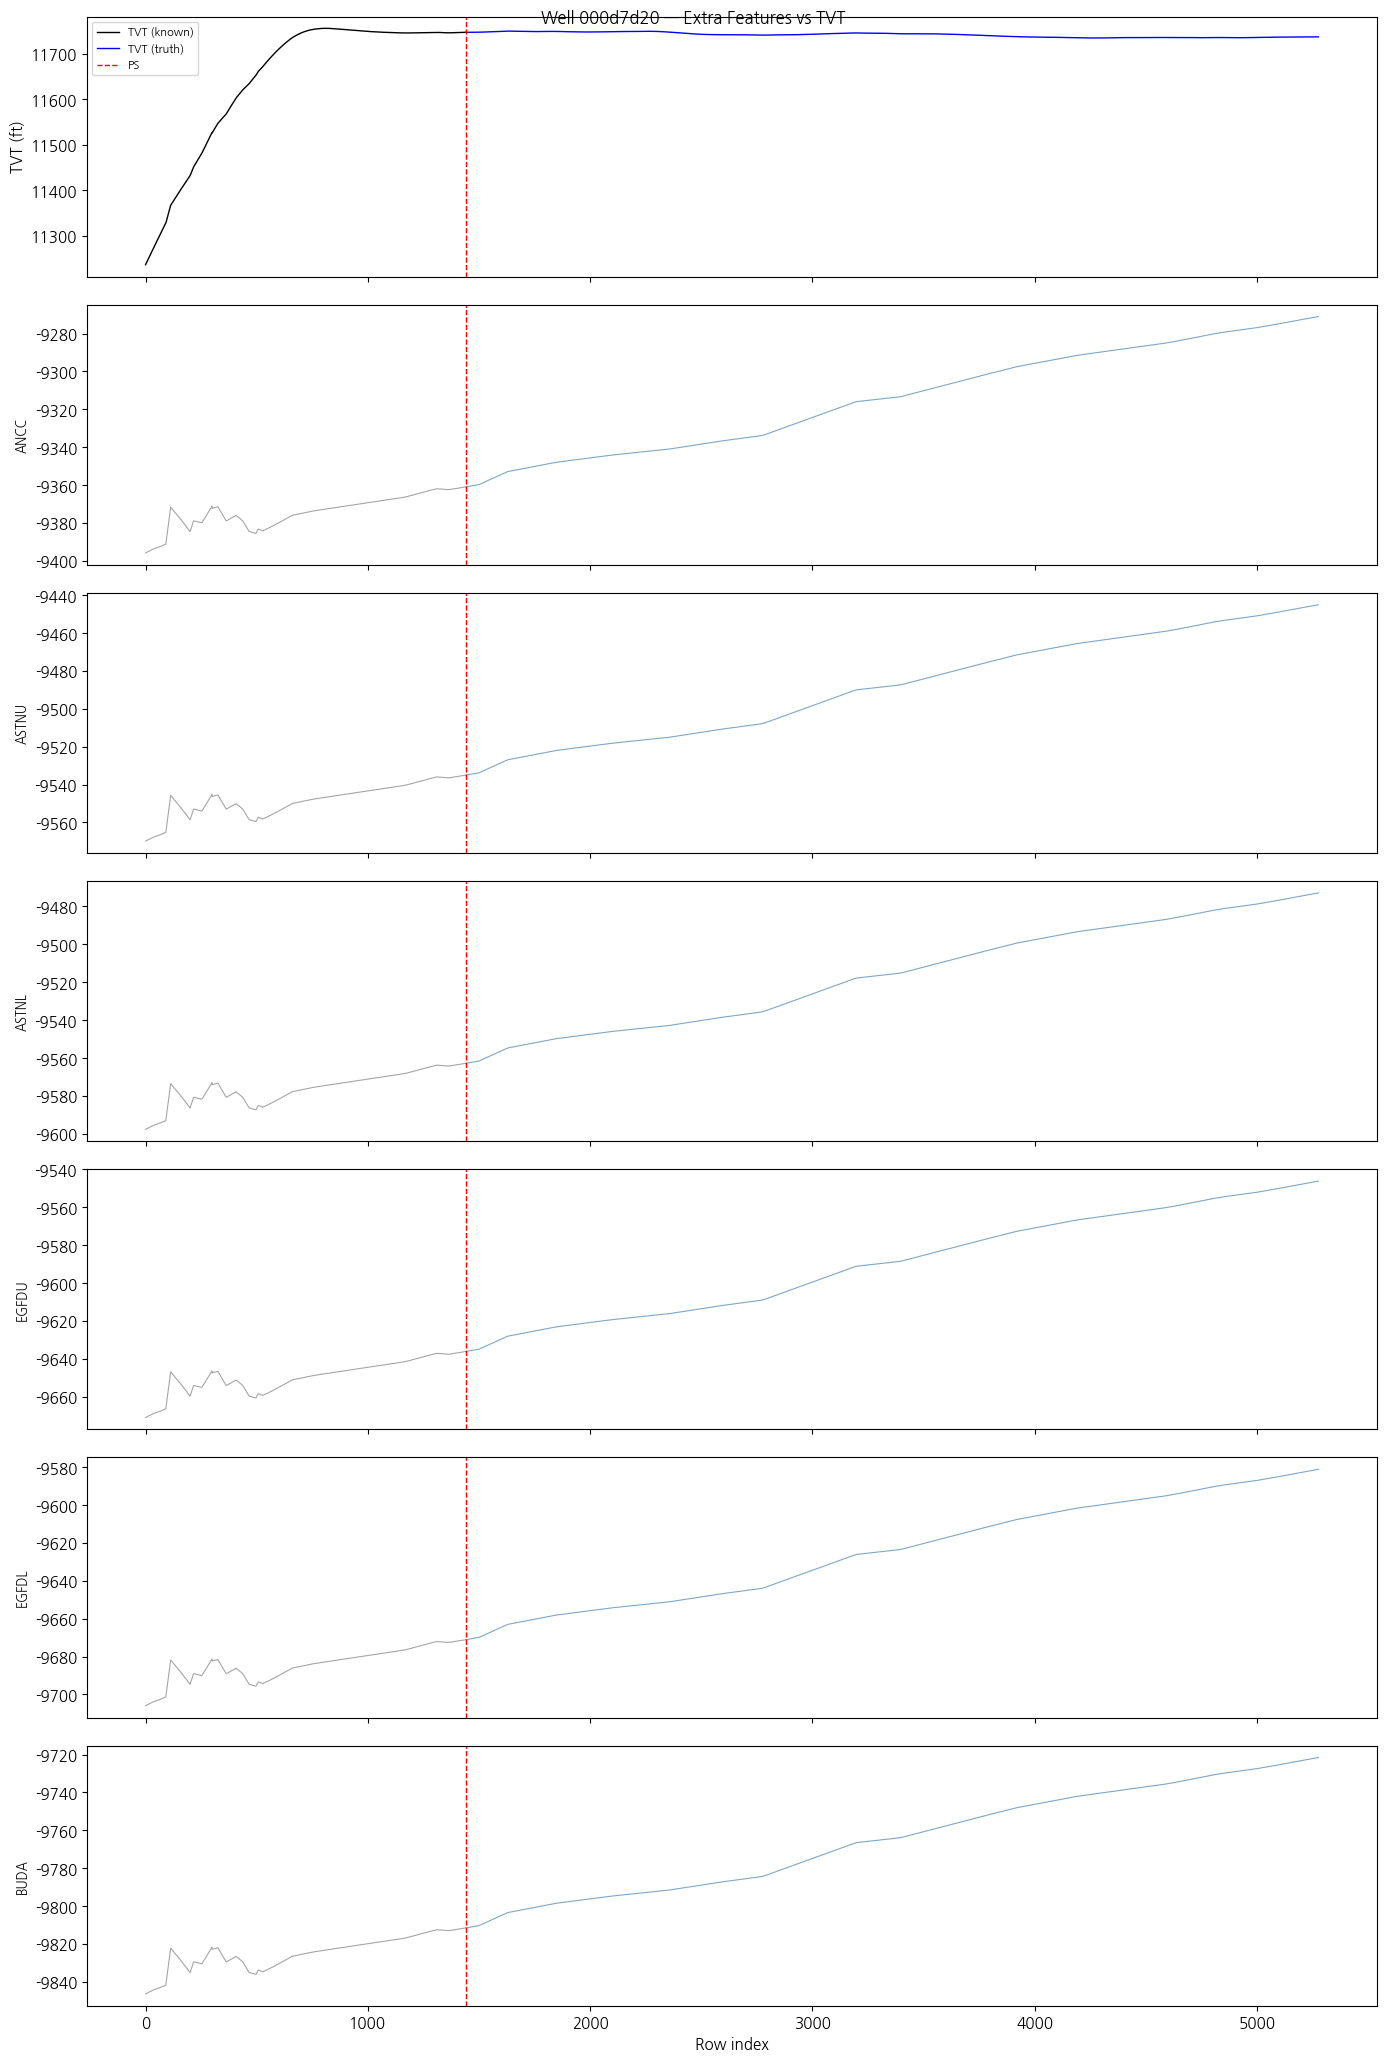

In [54]:
# ════════════════════════════════════════════════
# 셀 3. 시각화 — PS 전후 피처 값 변화
# ════════════════════════════════════════════════

available = [c for c in EXTRA_COLS if c in hw.columns and hw[c].notna().sum() > 10]
n_cols = len(available)

if n_cols == 0:
    print("분석 가능한 피처 없음")
else:
    fig, axes = plt.subplots(n_cols + 1, 1, figsize=(14, 3 * (n_cols + 1)), sharex=True)

    # TVT
    ax = axes[0]
    ax.plot(hw_before.index, hw_before['TVT_input'], color='black', lw=1, label='TVT (known)')
    ax.plot(hw_after.index,  hw_after['TVT'],        color='blue',  lw=1, label='TVT (truth)')
    ax.axvline(ps_idx, color='red', ls='--', lw=1, label='PS')
    ax.set_ylabel('TVT (ft)'); ax.legend(fontsize=8)

    for i, col in enumerate(available):
        ax = axes[i + 1]
        ax.plot(hw_before.index, hw_before[col], color='gray',    lw=0.8, alpha=0.7)
        ax.plot(hw_after.index,  hw_after[col],  color='steelblue', lw=0.8, alpha=0.7)
        ax.axvline(ps_idx, color='red', ls='--', lw=1)
        ax.set_ylabel(col, fontsize=9)

    axes[-1].set_xlabel('Row index')
    plt.suptitle(f'Well {TEST_WELL} — Extra Features vs TVT', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/ROGII/week4_features_single.png', dpi=120)
    plt.show()

count    766.000000
mean      -0.014325
std        0.189151
min       -2.790713
25%       -0.075358
50%       -0.003658
75%        0.064806
max        0.831717
Name: slope, dtype: float64

중앙값: -0.0037
표준편차: 0.1892


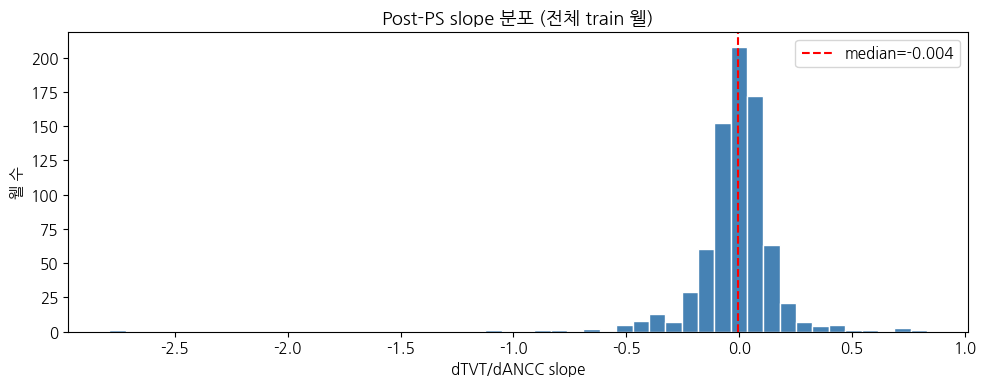

In [56]:
# 전체 train 웰에서 post-PS dTVT/dANCC 기울기 계산
slopes = []

for hw_path in hw_files:
    try:
        well_id = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
        hw = pd.read_csv(hw_path)
        ps_idx = hw['TVT_input'].last_valid_index()
        if ps_idx is None: continue

        hw_after = hw.loc[ps_idx+1:]
        common = hw_after[['TVT', 'ANCC']].dropna()
        if len(common) < 50: continue

        delta_tvt  = common['TVT'].iloc[-1]  - common['TVT'].iloc[0]
        delta_ancc = common['ANCC'].iloc[-1] - common['ANCC'].iloc[0]

        if abs(delta_ancc) > 0.1:
            slopes.append({
                'well': well_id,
                'slope': delta_tvt / delta_ancc,
                'delta_tvt': delta_tvt,
                'delta_ancc': delta_ancc
            })
    except: pass

sdf = pd.DataFrame(slopes)
print(sdf['slope'].describe())
print(f"\n중앙값: {sdf['slope'].median():.4f}")
print(f"표준편차: {sdf['slope'].std():.4f}")

# 분포 시각화
plt.figure(figsize=(10, 4))
plt.hist(sdf['slope'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(sdf['slope'].median(), color='red', ls='--', label=f"median={sdf['slope'].median():.3f}")
plt.xlabel('dTVT/dANCC slope'); plt.ylabel('웰 수')
plt.title('Post-PS slope 분포 (전체 train 웰)')
plt.legend(); plt.tight_layout(); plt.show()

In [57]:
tw = pd.read_csv(f'{TRAIN_PATH}/000d7d20__typewell.csv')
print(tw['Geology'].value_counts())
print(tw[['TVT', 'GR', 'Geology']].head(20))

Geology
ANCC     348
ASTNL    146
EGFDL    121
BUDA      96
LBHL      74
EGFDU     70
ASTNU     56
LTHL      31
LTGT      28
MNSS      27
Name: count, dtype: int64
         TVT      GR Geology
0   11223.95  126.11     NaN
1   11224.45  128.22     NaN
2   11224.95  128.72     NaN
3   11225.45  128.12     NaN
4   11225.95  125.29     NaN
5   11226.45  119.03     NaN
6   11226.95  111.77     NaN
7   11227.45  106.81     NaN
8   11227.95  103.32     NaN
9   11228.45  100.14     NaN
10  11228.95   98.77     NaN
11  11229.45   99.75     NaN
12  11229.95  102.43     NaN
13  11230.45  106.36     NaN
14  11230.95  111.34     NaN
15  11231.45  117.74     NaN
16  11231.95  122.77     NaN
17  11232.45  121.42     NaN
18  11232.95  114.61     NaN
19  11233.45  109.08     NaN


In [58]:
ps_tvt = 11747.37

# PS 시점 Typewell 지층 확인
tw_at_ps = tw.iloc[(tw['TVT'] - ps_tvt).abs().argsort()[:10]]
print(tw_at_ps[['TVT', 'GR', 'Geology']])

# 각 지층별 TVT 범위
for geo in tw['Geology'].dropna().unique():
    sub = tw[tw['Geology'] == geo]['TVT']
    print(f"{geo}: {sub.min():.1f} ~ {sub.max():.1f} ft  ({len(sub)} rows)")

           TVT      GR Geology
1047  11747.45   93.57    LTHL
1046  11746.95   91.96    LTHL
1048  11747.95   97.78    LTHL
1045  11746.45   94.67    LTHL
1049  11748.45   99.29    LTHL
1044  11745.95  100.77    LTHL
1050  11748.95   96.51    LTHL
1043  11745.45  111.24    LTHL
1051  11749.45   90.61    LTHL
1042  11744.95  123.41    LTHL
ANCC: 11373.5 ~ 11547.0 ft  (348 rows)
ASTNU: 11547.5 ~ 11575.0 ft  (56 rows)
ASTNL: 11575.5 ~ 11648.0 ft  (146 rows)
EGFDU: 11648.5 ~ 11683.0 ft  (70 rows)
EGFDL: 11683.5 ~ 11743.5 ft  (121 rows)
LTHL: 11744.0 ~ 11759.0 ft  (31 rows)
LTGT: 11759.5 ~ 11773.0 ft  (28 rows)
LBHL: 11773.5 ~ 11810.0 ft  (74 rows)
MNSS: 11810.5 ~ 11823.5 ft  (27 rows)
BUDA: 11824.0 ~ 11871.5 ft  (96 rows)


In [59]:
# 피처값 + datum = 지층 TVT인지 확인
formations = {
    'ANCC': (11373+11547)/2,
    'ASTNL': (11575+11648)/2,
    'EGFDU': (11648+11683)/2,
    'EGFDL': (11683+11743)/2,
    'BUDA':  (11824+11871)/2
}

for feat, tvt_mid in formations.items():
    feat_val = hw.loc[ps_idx, feat]
    offset = tvt_mid + feat_val  # feat은 음수
    print(f"{feat}: feature={feat_val:.1f}, TVT_mid={tvt_mid:.1f}, offset={offset:.1f}")

ANCC: feature=-10426.1, TVT_mid=11460.0, offset=1033.9
ASTNL: feature=-10644.4, TVT_mid=11611.5, offset=967.1
EGFDU: feature=-10666.4, TVT_mid=11665.5, offset=999.1
EGFDL: feature=-10711.1, TVT_mid=11713.0, offset=1001.9
BUDA: feature=-10883.5, TVT_mid=11847.5, offset=964.0


In [61]:
hw_test   = pd.read_csv(f'{TRAIN_PATH}/000d7d20__horizontal_well.csv')
ps_idx    = hw_test['TVT_input'].last_valid_index()
hw_before = hw_test.loc[:ps_idx]
hw_after  = hw_test.loc[ps_idx + 1:]
last_tvt  = hw_before['TVT_input'].dropna().iloc[-1]
true_tvt  = hw_after['TVT'].dropna()

egfdl_ps       = hw_test.loc[ps_idx, 'EGFDL']
egfdl_offset   = 1001.9
drill_to_egfdl = last_tvt - (hw_test.loc[ps_idx, 'EGFDL'].item().__abs__() + egfdl_offset)

print(f"EGFDL at PS: {egfdl_ps:.2f}")
print(f"드릴 → EGFDL 거리: {drill_to_egfdl:.2f} ft")  # ~34 ft 나와야 정상

pred   = hw_after['EGFDL'].abs() + egfdl_offset + drill_to_egfdl
pred   = pred.clip(last_tvt - 40, last_tvt + 40)
common = true_tvt.index.intersection(pred.index)
rmse   = np.sqrt(mean_squared_error(true_tvt.loc[common], pred.loc[common]))
print(f"EGFDL-based: {rmse:.4f} ft  (Constant: 7.4544 ft)")

EGFDL at PS: -9671.12
드릴 → EGFDL 거리: 1074.35 ft
EGFDL-based: 27.1183 ft  (Constant: 7.4544 ft)


In [63]:
"""
Week 4: Cross-Well XGB (핵심 아이디어)
─────────────────────────────────────────────────────────────
이전 실패 원인:
  - Linear / EGF regression: 같은 웰 PS이전 데이터로 학습 → PS이후 예측
  - PS이전 corr=+0.72 vs PS이후 corr=-0.91 → 방향 반전으로 완전히 틀린 예측

새 접근:
  - 전체 773웰의 PS이후 데이터를 학습셋으로 사용
  - Features: 각 피처의 PS 대비 변화량(delta) + GR + MD_offset
  - Target: TVT_delta = TVT - last_tvt
  - 평가: Leave-One-Out (각 웰을 test로, 나머지로 학습)

실행 방법 (Google Colab):
  셀 1 → 2 → 3 → 4 → 5
"""

# ════════════════════════════════════════════════
# 셀 1. 설정
# ════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import glob, os, warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/ROGII/train'
EXTRA_COLS = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']

hw_files = sorted(glob.glob(f'{TRAIN_PATH}/*__horizontal_well.csv'))
print(f"train 웰 수: {len(hw_files)}")


# ════════════════════════════════════════════════
# 셀 2. 전체 웰 PS 이후 데이터 수집
# ════════════════════════════════════════════════

def extract_post_ps(hw_path):
    """
    한 웰에서 PS 이후 행들을 추출.
    피처: PS 대비 delta값 + GR + MD_offset
    """
    well_id = os.path.basename(hw_path).replace('__horizontal_well.csv', '')
    hw = pd.read_csv(hw_path)

    ps_idx = hw['TVT_input'].last_valid_index()
    if ps_idx is None:
        return None

    hw_before = hw.loc[:ps_idx]
    hw_after  = hw.loc[ps_idx + 1:]
    true_tvt  = hw_after['TVT'].dropna()
    if len(true_tvt) < 5:
        return None

    last_tvt = hw_before['TVT_input'].dropna().iloc[-1]
    last_md  = hw.loc[ps_idx, 'MD']

    # PS 시점 피처값
    ps_feats = {}
    for col in EXTRA_COLS:
        if col in hw.columns:
            ps_feats[col] = hw.loc[ps_idx, col]
        else:
            ps_feats[col] = np.nan

    # PS 이후 행별 피처 구성
    rows = hw_after.copy()
    rows['TVT_delta'] = rows['TVT'] - last_tvt     # target
    rows['MD_offset'] = rows['MD'] - last_md        # MD 변화량

    for col in EXTRA_COLS:
        if col in rows.columns and not np.isnan(ps_feats[col]):
            rows[f'{col}_delta'] = rows[col] - ps_feats[col]
        else:
            rows[f'{col}_delta'] = np.nan

    rows['well_id']  = well_id
    rows['last_tvt'] = last_tvt

    feat_cols = ['GR', 'MD_offset'] + [f'{c}_delta' for c in EXTRA_COLS]
    keep = feat_cols + ['TVT_delta', 'TVT', 'well_id', 'last_tvt']
    available = [c for c in keep if c in rows.columns]

    result = rows[available].dropna(subset=['TVT_delta'])
    return result

print("데이터 수집 중...")
all_rows = []
for p in hw_files:
    r = extract_post_ps(p)
    if r is not None:
        all_rows.append(r)

all_df = pd.concat(all_rows, ignore_index=True)
print(f"전체 PS이후 행: {len(all_df):,}  (웰 수: {all_df['well_id'].nunique()})")
print(f"TVT_delta 범위: {all_df['TVT_delta'].min():.1f} ~ {all_df['TVT_delta'].max():.1f} ft")
print(f"TVT_delta 평균: {all_df['TVT_delta'].mean():.3f} ft,  중앙값: {all_df['TVT_delta'].median():.3f} ft")


# ════════════════════════════════════════════════
# 셀 3. 피처 중요도 확인 (전체 데이터 학습)
# ════════════════════════════════════════════════

from xgboost import XGBRegressor

FEAT_COLS = ['GR', 'MD_offset'] + [f'{c}_delta' for c in EXTRA_COLS]
FEAT_COLS = [c for c in FEAT_COLS if c in all_df.columns]

X_all = all_df[FEAT_COLS].fillna(0)
y_all = all_df['TVT_delta']

xgb_global = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, verbosity=0,
    random_state=42
)
xgb_global.fit(X_all, y_all)

print("[전체 데이터 기준 피처 중요도]")
for feat, imp in sorted(zip(FEAT_COLS, xgb_global.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat:<18} {imp:.4f}")


# ════════════════════════════════════════════════
# 셀 4. 5-Fold CV
# ════════════════════════════════════════════════

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

wells = np.array(all_df['well_id'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for fold, (tr_idx, te_idx) in enumerate(kf.split(wells)):
    train_wells = set(wells[tr_idx])
    test_wells  = set(wells[te_idx])

    train_mask = all_df['well_id'].isin(train_wells)
    test_mask  = all_df['well_id'].isin(test_wells)

    X_tr = all_df.loc[train_mask, FEAT_COLS].fillna(0)
    y_tr = all_df.loc[train_mask, 'TVT_delta']
    X_te = all_df.loc[test_mask,  FEAT_COLS].fillna(0)

    xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, verbosity=0, random_state=42)
    xgb.fit(X_tr, y_tr)
    preds_delta = xgb.predict(X_te)
    print(f"Fold {fold+1}/5 완료")

    all_df_test = all_df.loc[test_mask].copy()
    all_df_test['pred_tvt'] = all_df_test['last_tvt'] + np.clip(preds_delta, -50, 50)

    for well_id, grp in all_df_test.groupby('well_id'):
        true_tvt = grp['TVT']
        last_tvt = grp['last_tvt'].iloc[0]
        rmse_const = np.sqrt(mean_squared_error(true_tvt, np.full(len(true_tvt), last_tvt)))
        rmse_xgb   = np.sqrt(mean_squared_error(true_tvt, grp['pred_tvt']))
        results.append({'well': well_id, 'n': len(grp),
                        'rmse_const': rmse_const, 'rmse_xgb': rmse_xgb})

df_res = pd.DataFrame(results)
w = df_res['n']
for col, label in [('rmse_const','Constant'), ('rmse_xgb','CrossWell-XGB')]:
    print(f"{label}: 단순={df_res[col].mean():.4f}  가중={(df_res[col]*w).sum()/w.sum():.4f}")
print(f"XGB < Constant: {(df_res['rmse_xgb']<df_res['rmse_const']).sum()}/{len(df_res)} 웰")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train 웰 수: 773
데이터 수집 중...
전체 PS이후 행: 3,783,989  (웰 수: 773)
TVT_delta 범위: -103.8 ~ 98.9 ft
TVT_delta 평균: 1.596 ft,  중앙값: 0.840 ft
[전체 데이터 기준 피처 중요도]
  BUDA_delta         0.1662
  ASTNU_delta        0.1629
  MD_offset          0.1433
  EGFDU_delta        0.1360
  EGFDL_delta        0.1316
  ASTNL_delta        0.1218
  ANCC_delta         0.0995
  GR                 0.0387
Fold 1/5 완료
Fold 2/5 완료
Fold 3/5 완료
Fold 4/5 완료
Fold 5/5 완료
Constant: 단순=12.8125  가중=13.0883
CrossWell-XGB: 단순=12.7452  가중=12.9677
XGB < Constant: 410/773 웰
